# Bhoomathon — AI-Driven Coal Quality Estimation
## IAMG-IIT Bombay Student Chapter

**Theme:** AI-driven coal quality estimation using geophysical data  
**Objective:** Predict Gross Calorific Value (GCV) of coal seams from geophysical well logs using Machine Learning  

---

### Methodology Overview

This notebook follows the methodology outlined in Figure 1 of our submission:

1. **Data Collection** — LAS files (Well 17 & Well 22) + XLSX lab-calibrated files
2. **Data Pre-processing** — Removal of missing values, standardisation, scaling, data cleaning
3. **Feature Engineering & Selection** — Correlation matrix, feature scaling, importance ranking, derived features
4. **Machine Learning Algorithms** — XGBoost, Random Forest, Linear Regression, Multi-layer Perceptron
5. **Model Training, Testing & Application** — Train/test on XLSX, GridSearchCV tuning, apply to LAS files
6. **Model Evaluation & Comparison** — MAE, RMSE, MAPE, R², ISP 2022 coal grading

### GCV Formula (B.K. Mazumdar, 1954)

$$\text{GCV} = 85.6 \times [100 - (1.1 \times A + M)] - 60 \times M \quad \text{(Kcal/kg)}$$

where $A$ = Ash (%) and $M$ = Moisture (%)

---
## Cell 1 — Install Required Libraries

Run this cell once before starting. Restart the kernel after installation.

In [25]:
# Install all required libraries
# Run this cell once, then restart the kernel

import subprocess

packages = [
    'lasio',          # Reading LAS well log files
    'pandas',         # Data manipulation and analysis
    'numpy',          # Numerical computing
    'matplotlib',     # Plotting and visualisation
    'seaborn',        # Statistical visualisation
    'scikit-learn',   # Machine learning models and utilities
    'xgboost',        # Extreme Gradient Boosting
    'openpyxl',       # Reading .xlsx Excel files
    'scipy',          # Statistical tests
]

for pkg in packages:
    subprocess.run(['pip', 'install', pkg, '-q'], check=True)

print('All libraries installed successfully.')

All libraries installed successfully.


---
## Cell 2 — Import Libraries and Print Versions

All imports are consolidated here. Versions are printed for reproducibility documentation.

In [1]:
# Standard library
import warnings
warnings.filterwarnings('ignore')

# Data handling
import lasio
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

# Machine learning — preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    cross_val_predict,
    KFold,
    GridSearchCV
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Machine learning — models (as per methodology image)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import xgboost as xgb

# Statistical testing
from scipy import stats

# Print versions for reproducibility
import sklearn
print('Library versions (include these in your technical report):')
print(f'  Python      : 3.x')
print(f'  pandas      : {pd.__version__}')
print(f'  numpy       : {np.__version__}')
print(f'  lasio       : {lasio.__version__}')
print(f'  scikit-learn: {sklearn.__version__}')
print(f'  xgboost     : {xgb.__version__}')

Library versions (include these in your technical report):
  Python      : 3.x
  pandas      : 2.3.2
  numpy       : 2.3.2
  lasio       : 0.32
  scikit-learn: 1.8.0
  xgboost     : 3.2.0


---
# Step 1 — Data Collection

We collect data from two sources:
- **LAS files** (Well 17 & Well 22): continuous geophysical log readings at every 0.1 m depth — Density, Natural Gamma, Resistivity, Caliper, P-velocity, S-velocity
- **XLSX files** (Well 17 & Well 22): lab-measured ash% and moisture% at specific sampled depths

The LAS data provides the **features (X)** and the lab data provides the basis for the **target (GCV = y)**.

## Cell 3 — File Path Configuration

**Update the paths below to match your folder structure before running.**

In [2]:
# ── UPDATE THESE FILE PATHS BEFORE RUNNING ──────────────────────────────────

# Lab-calibrated XLSX files (contain Ash%, Moisture% at sampled depths)
PATH_LAB_WELL17 = "well17_lab_calibrated.xlsx"
PATH_LAB_WELL22 = "well22_lab_calibrated.xlsx"

# LAS well log files (continuous geophysical readings every 0.1 m)
PATH_LAS_WELL17 = "Well17_las.las"
PATH_LAS_WELL22 = "Well22_LAS.las"

# ────────────────────────────────────────────────────────────────────────────

# Random seed for reproducibility across all models
RANDOM_STATE = 42

# LAS null value standard (industry-wide convention)
LAS_NULL = -999.25

print('File paths configured.')
print('Random state:', RANDOM_STATE)

File paths configured.
Random state: 42


## Cell 4 — Load XLSX Lab Files

In [3]:
def load_lab_file(path, well_name):
    """
    Load a lab-calibrated Excel file and prepare it for ML.

    Steps:
    1. Read the Excel file into a DataFrame
    2. Standardise column names (lowercase + underscores)
    3. Compute GCV using B.K. Mazumdar (1954) formula
    4. Tag rows with the well name for later identification

    Parameters
    ----------
    path      : str — path to the .xlsx file
    well_name : str — label for this well (e.g. 'Well17')

    Returns
    -------
    pd.DataFrame
    """
    # Read the Excel file
    df = pd.read_excel(path)

    # Standardise column names across both wells
    # Well 17 uses 'depth', Well 22 uses 'Depth' — this normalises both
    df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]

    # Ensure the depth column is consistently named 'depth'
    if 'depth' not in df.columns:
        df.rename(columns={df.columns[0]: 'depth'}, inplace=True)

    # Compute GCV using B.K. Mazumdar formula
    # GCV = 85.6 × [100 − (1.1 × Ash + Moisture)] − 60 × Moisture
    df['gcv'] = (
        85.6 * (100 - (1.1 * df['ash'] + df['moisture']))
        - 60 * df['moisture']
    )

    # Tag each row with the well name
    df['well'] = well_name

    return df


# Load lab data for both wells
lab_well17 = load_lab_file(PATH_LAB_WELL17, 'Well17')
lab_well22 = load_lab_file(PATH_LAB_WELL22, 'Well22')

# Display summary
print('Lab data loaded successfully.')
print(f'  Well 17: {len(lab_well17)} samples, '
      f'depth {lab_well17.depth.min():.1f}–{lab_well17.depth.max():.1f} m, '
      f'GCV {lab_well17.gcv.min():.0f}–{lab_well17.gcv.max():.0f} Kcal/kg')
print(f'  Well 22: {len(lab_well22)} samples, '
      f'depth {lab_well22.depth.min():.1f}–{lab_well22.depth.max():.1f} m, '
      f'GCV {lab_well22.gcv.min():.0f}–{lab_well22.gcv.max():.0f} Kcal/kg')
print()
print('Columns:', lab_well17.columns.tolist())
lab_well17.head(3)

Lab data loaded successfully.
  Well 17: 193 samples, depth 45.1–588.7 m, GCV 358–6030 Kcal/kg
  Well 22: 202 samples, depth 43.6–534.3 m, GCV -68–5660 Kcal/kg

Columns: ['depth', 'caliper', 'density', 'natural_gamma', 'resistivity', 'p_slowness', 's_slowness', 'p_velocity', 's_velocity', 'lithology', 'moisture', 'ash', 'coalseam', 'vm%', 'fc%', 'gcv', 'grade', 'well']


,depth,caliper,density,natural_gamma,resistivity,p_slowness,s_slowness,p_velocity,s_velocity,lithology,moisture,ash,coalseam,vm%,fc%,gcv,grade,well
0,45.1,10.33191,1.920818,214.24550,56.26306,462.50,564.58,2162.16,1771.23,SHALY COAL,5.378168,49.570773,RT,NaN,NaN,3109.354786,G-14,Well17
1,45.5,10.31800,1.616891,152.84000,52.46987,475.00,608.33,2105.26,1643.84,SHALY COAL,6.677329,40.228046,RT,NaN,NaN,3799.908113,G-12,Well17
2,46.7,10.26291,1.496330,92.49954,102.12830,479.17,608.33,2086.96,1643.84,COAL,9.617497,22.836538,RT,NaN,NaN,5009.403938,G-8,Well17


## Cell 5 — Load LAS Files

In [4]:
def load_las_file(path):
    """
    Load a LAS well log file and prepare it for ML.

    Steps:
    1. Read the LAS file using lasio
    2. Convert to pandas DataFrame
    3. Standardise column names to lowercase
    4. Replace LAS null values (-999.25) with NaN

    Parameters
    ----------
    path : str — path to the LAS file

    Returns
    -------
    pd.DataFrame
    """
    # Read the LAS file
    las = lasio.read(path)

    # Convert to DataFrame; reset_index() moves depth into a regular column
    df = las.df().reset_index()

    # Lowercase all column names for consistency
    df.columns = [col.lower() for col in df.columns]

    # Replace the industry-standard null value (-999.25) with NaN
    # This ensures missing values are handled correctly by pandas/sklearn
    df.replace(LAS_NULL, np.nan, inplace=True)

    return df


# Load LAS files for both wells
las_well17 = load_las_file(PATH_LAS_WELL17)
las_well22 = load_las_file(PATH_LAS_WELL22)

# Display summary
print('LAS files loaded successfully.')
print(f'  Well 17: {las_well17.shape[0]} depth points, '
      f'{las_well17.shape[1]} curves')
print(f'    Depth: {las_well17.dept.min():.1f}–{las_well17.dept.max():.1f} m')
print(f'    Curves: {las_well17.columns.tolist()}')
print()
print(f'  Well 22: {las_well22.shape[0]} depth points, '
      f'{las_well22.shape[1]} curves')
print(f'    Depth: {las_well22.dept.min():.1f}–{las_well22.dept.max():.1f} m')
print()
print('Missing values per curve (Well 17):')
print(las_well17.isnull().sum())

LAS files loaded successfully.
  Well 17: 5563 depth points, 9 curves
    Depth: 37.8–594.0 m
    Curves: ['dept', 'sonic_velocity', 'calp', 'dens', 'ngam', 'res', 'shear_slowness', 'shear_velocity', 'sonic_slowness']

  Well 22: 26999 depth points, 9 curves
    Depth: 0.0–540.0 m

Missing values per curve (Well 17):
dept              0
sonic_velocity    0
calp              1
dens              2
ngam              1
res               1
shear_slowness    0
shear_velocity    0
sonic_slowness    0
dtype: int64


---
# Step 2 — Data Pre-processing

We perform four operations:
1. **Remove missing values & undefined entries** — drop rows where key log curves are NaN
2. **Merge XLSX + LAS by depth** — match each lab sample to its nearest LAS reading (within 15 cm)
3. **Combine both wells** — create one unified dataset for training
4. **Data standardisation & scaling** — zero mean, unit variance (critical for MLP and Linear Regression)

## Cell 6 — Merge XLSX Lab Data with LAS Log Data

In [5]:
def merge_lab_with_las(lab_df, las_df, depth_tolerance=0.15):
    """
    Join lab data (sparse, sampled depths) with LAS data
    (dense, every 0.1 m) using a nearest-depth join.

    pd.merge_asof matches each lab row to the nearest LAS row
    within the specified depth tolerance. This is necessary because
    lab depths (e.g. 45.1 m) rarely exactly match LAS depths (e.g. 45.1000 m).

    Parameters
    ----------
    lab_df          : pd.DataFrame — lab data with 'depth' column
    las_df          : pd.DataFrame — LAS data with 'dept' column
    depth_tolerance : float — max allowed depth gap in metres (default 0.15 m)

    Returns
    -------
    pd.DataFrame — merged dataset with both lab and log values per row
    """
    # Both DataFrames must be sorted by the key column for merge_asof
    merged = pd.merge_asof(
        lab_df.sort_values('depth'),
        las_df.sort_values('dept'),
        left_on='depth',
        right_on='dept',
        tolerance=depth_tolerance,
        direction='nearest'
    )

    return merged


# Merge lab + LAS for each well separately
merged_well17 = merge_lab_with_las(lab_well17, las_well17)
merged_well22 = merge_lab_with_las(lab_well22, las_well22)

print(f'Merged Well 17: {len(merged_well17)} rows')
print(f'Merged Well 22: {len(merged_well22)} rows')

Merged Well 17: 193 rows
Merged Well 22: 202 rows


## Cell 7 — Remove Missing Values & Combine Both Wells

In [6]:
# Define key log curves that must be present
# Rows missing any of these columns will be dropped
REQUIRED_CURVES = ['sonic_velocity', 'dens', 'ngam', 'res', 'shear_slowness', 'moisture', 'ash', 'gcv']

# Remove rows where key log curves are missing
merged_well17.dropna(subset=REQUIRED_CURVES, inplace=True)
merged_well22.dropna(subset=REQUIRED_CURVES, inplace=True)

merged_well17.reset_index(drop=True, inplace=True)
merged_well22.reset_index(drop=True, inplace=True)

print(f'After removing missing values:')
print(f'  Well 17: {len(merged_well17)} samples')
print(f'  Well 22: {len(merged_well22)} samples')

# Combine both wells into a single dataset
# pd.concat stacks the two DataFrames row-wise
# ignore_index=True resets row numbers from 0 in the combined table
combined = pd.concat([merged_well17, merged_well22], ignore_index=True)

print(f'  Combined : {len(combined)} samples')
print()
print('Lithology distribution (combined):')
print(combined['lithology'].value_counts())

After removing missing values:
  Well 17: 193 samples
  Well 22: 202 samples
  Combined : 395 samples

Lithology distribution (combined):
lithology
SHALY COAL         156
CARB SHALE LOW      93
COAL                74
SHALE               37
CARB SHALE HIGH     34
SANDSTONE            1
Name: count, dtype: int64


---
# Step 3 — Feature Engineering & Selection

We create new features by combining existing log curves. This uses domain knowledge:
- **Vp/Vs ratio**: ~1.5 for coal, ~1.7 for shale — strong lithology discriminator
- **Acoustic impedance** (ρ × Vp): links to seismic reflection — used in interpretation
- **log(Resistivity)**: coal has very high resistivity (100–1000 Ω·m); log-transform prevents outlier dominance

We also run a **correlation matrix** and **feature importance ranking** to confirm which inputs matter most.

## Cell 8 — Create Derived Features

In [7]:
def add_derived_features(df):
    """
    Add five derived geophysical features to the DataFrame.

    These features combine existing log curves to capture physical
    properties that individual curves cannot express alone.

    Parameters
    ----------
    df : pd.DataFrame — merged lab + LAS DataFrame

    Returns
    -------
    pd.DataFrame — same DataFrame with 5 new columns added
    """
    df = df.copy()

    # Vp/Vs ratio — separates coal (~1.5) from shale (~1.7)
    df['vp_vs_ratio'] = df['sonic_velocity'] / df['shear_velocity'].replace(0, np.nan)

    # Acoustic impedance Z = density × P-velocity (g/cc × m/s)
    df['acoustic_imp'] = df['dens'] * df['sonic_velocity']

    # Shear impedance = density × S-velocity
    df['shear_imp'] = df['dens'] * df['shear_velocity']

    # P-velocity minus S-velocity — velocity contrast between wave types
    df['vp_minus_vs'] = df['sonic_velocity'] - df['shear_velocity']

    # Log-transformed resistivity — coal has very high values (100–1000 Ω·m)
    # np.log1p = log(1 + x), handles zero values gracefully
    df['log_resistivity'] = np.log1p(df['res'])

    return df


# Apply feature engineering to the combined dataset
combined = add_derived_features(combined)

# Define the complete feature list used for ML
# 6 raw log curves + 5 derived features = 11 features total
FEATURES_CORR = [
    'dens',             # Bulk density (g/cc) — most important for coal quality
    'ngam',             # Natural gamma ray (API) — low in coal, high in shale
    'log_resistivity',  # Log-transformed resistivity — very high in coal
    'sonic_velocity',   # P-wave velocity (m/s)
    'shear_velocity',   # S-wave velocity (m/s)
    'sonic_slowness',   # P-wave slowness (µs/m)
    'shear_slowness',   # S-wave slowness (µs/m)
    'vp_vs_ratio',      # Vp/Vs ratio — lithology indicator
    'acoustic_imp',     # Acoustic impedance (ρ × Vp)
    'shear_imp',        # Shear impedance (ρ × Vs)
    'vp_minus_vs',      # Velocity difference (Vp − Vs)   
    'moisture',
    'ash'
]


FEATURES = [
    'dens',             # Bulk density (g/cc) — most important for coal quality
    'ngam',             # Natural gamma ray (API) — low in coal, high in shale
    'log_resistivity',  # Log-transformed resistivity — very high in coal
    'sonic_velocity',   # P-wave velocity (m/s)
    'shear_velocity',   # S-wave velocity (m/s)
    'sonic_slowness',   # P-wave slowness (µs/m)
    'shear_slowness',   # S-wave slowness (µs/m)
    'vp_vs_ratio',      # Vp/Vs ratio — lithology indicator
    'acoustic_imp',     # Acoustic impedance (ρ × Vp)
    'shear_imp',        # Shear impedance (ρ × Vs)
    'vp_minus_vs',      # Velocity difference (Vp − Vs) 
]
#CHAINED PREDICTION FLOW
#1 Predict ash from density, resisitivity, and natural gamma
#2 Predict Moisture from above parameters + predicted ash in the first step
#3 Predict GCV from above parameters + predicted ash + predicted moisture from 1st and 2nd step

FEATURES_ASH = [
    'dens',            # Primary ash indicator: high-ash coal → higher density
    'ngam',            # Gamma ray: ash-rich shale bands give elevated GR
    'log_resistivity', # Low resistivity in ashy/wet intervals
]
FEATURES_MOISTURE = [
    'dens',            # Lower density often associated with higher moisture
    'ngam',            # Shale-rich intervals carry bound water
    'log_resistivity', # Wet intervals have reduced resistivity
    'ash_predicted',   # Carry forward Stage-1 output: ash and moisture co-vary
]

FEATURES_GCV_CHAIN = [
    'dens',
    'ngam',
    'log_resistivity',
    'ash_predicted',      # Stage-1 output
    'moisture_predicted' # Stage-2 output
]

# Extract feature matrix X and target vector y
X = combined[FEATURES].dropna()
y = combined.loc[X.index, 'gcv']
well_labels = combined.loc[X.index, 'well']

print(f'Feature matrix X: {X.shape}  (samples × features)')
print(f'Target vector y : {y.shape}')
print(f'  Well 17 samples: {(well_labels == "Well17").sum()}')
print(f'  Well 22 samples: {(well_labels == "Well22").sum()}')
print(f'\nGCV statistics (Kcal/kg):')
print(y.describe().round(1))

Feature matrix X: (395, 11)  (samples × features)
Target vector y : (395,)
  Well 17 samples: 193
  Well 22 samples: 202

GCV statistics (Kcal/kg):
count     395.0
mean     3269.5
std      1261.2
min       -68.3
25%      2548.3
50%      3302.6
75%      4177.4
max      6030.0
Name: gcv, dtype: float64


## Cell 9 — Data Standardisation (Feature Scaling)

In [8]:
# Standardise features: zero mean, unit variance
# Formula: z = (x - mean) / std
#
# Why scaling is necessary:
# - MLP (neural network) is very sensitive to feature magnitude
# - Linear Regression assumes features are on a comparable scale
# - density is ~1-3 g/cc but resistivity is ~30-1000 Ω·m — very different scales
# - Without scaling, high-magnitude features dominate the model
#
# Important: fit the scaler on training data only, then use transform() on new data

scaler = StandardScaler()

# fit_transform: compute mean/std from X, then apply the scaling
X_scaled = scaler.fit_transform(X)

# Verify: all columns should now have mean ≈ 0 and std ≈ 1
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES)
print('Scaling verification (mean should be ~0, std should be ~1):')
print(pd.DataFrame({
    'mean (before)': X.mean().round(2),
    'std  (before)': X.std().round(2),
    'mean (after) ': X_scaled_df.mean().round(4),
    'std  (after) ': X_scaled_df.std().round(4),
}))

Scaling verification (mean should be ~0, std should be ~1):
                 mean (before)  std  (before)  mean (after)   std  (after) 
dens                      1.76           0.19           -0.0         1.0013
ngam                    142.38          50.38           -0.0         1.0013
log_resistivity           4.99           0.60           -0.0         1.0013
sonic_velocity         2644.03         404.92           -0.0         1.0013
shear_velocity         1935.05         287.63            0.0         1.0013
sonic_slowness          386.43          53.23            0.0         1.0013
shear_slowness          527.83          73.47            0.0         1.0013
vp_vs_ratio               1.37           0.09           -0.0         1.0013
acoustic_imp           4645.71         886.25            0.0         1.0013
shear_imp              3401.20         643.07            0.0         1.0013
vp_minus_vs             708.98         193.55           -0.0         1.0013


## Cell 10 — Correlation Matrix Analysis

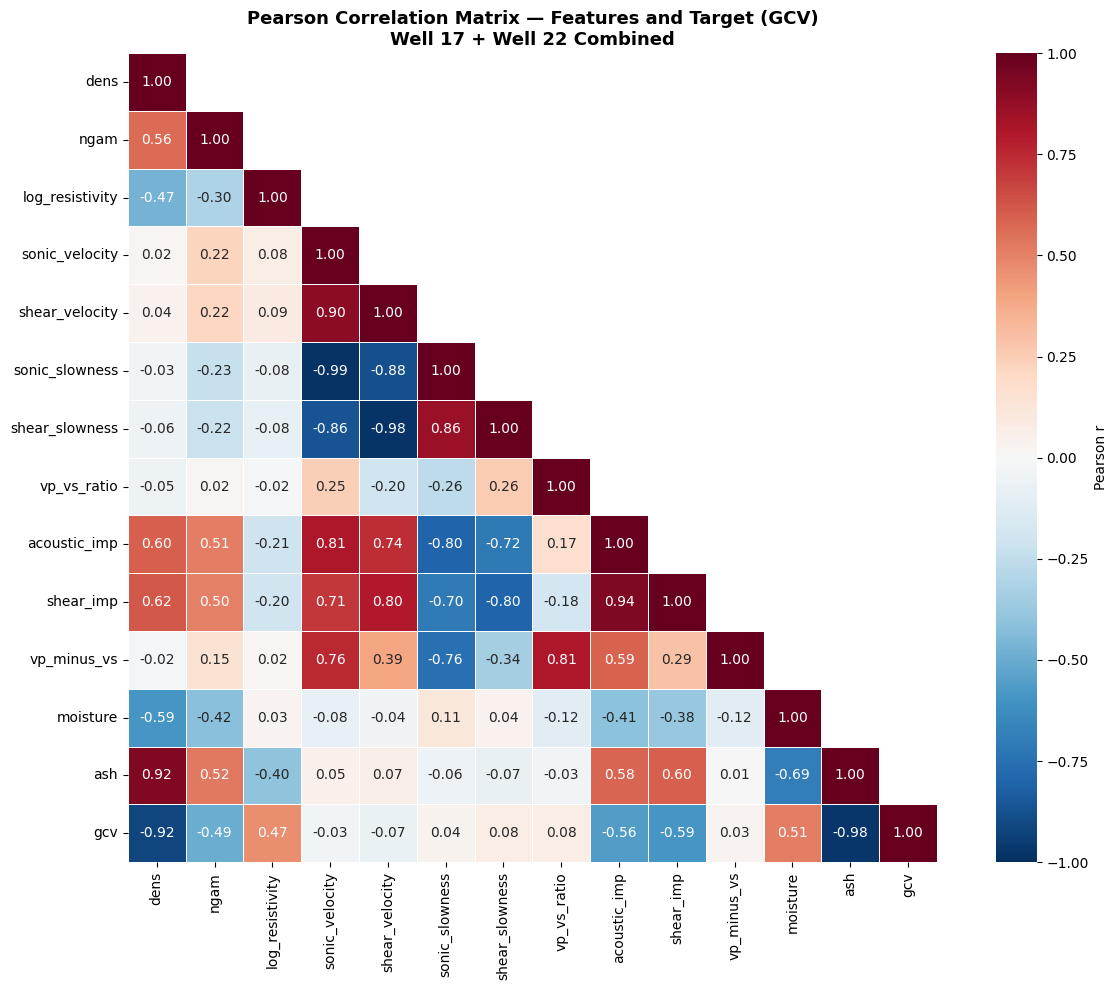

Feature correlation with GCV (|Pearson r|, sorted):
  ash                    0.975  ███████████████████████████████████████
  dens                   0.915  ████████████████████████████████████
  shear_imp              0.591  ███████████████████████
  acoustic_imp           0.560  ██████████████████████
  moisture               0.512  ████████████████████
  ngam                   0.494  ███████████████████
  log_resistivity        0.467  ██████████████████
  vp_vs_ratio            0.076  ███
  shear_slowness         0.075  ███
  shear_velocity         0.065  ██
  sonic_slowness         0.037  █
  sonic_velocity         0.034  █
  vp_minus_vs            0.026  █


In [9]:
# Build Pearson correlation matrix (features + target GCV)
# Pearson r: -1 = perfect negative, 0 = no linear relation, +1 = perfect positive

corr_data = combined[FEATURES_CORR].assign(gcv=y.values)
corr_matrix = corr_data.corr()

# Plot lower triangle only (avoids redundancy)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title(
    'Pearson Correlation Matrix — Features and Target (GCV)\n'
    'Well 17 + Well 22 Combined',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print correlations with GCV sorted by absolute value
gcv_corr = corr_matrix['gcv'].drop('gcv').abs().sort_values(ascending=False)
print('Feature correlation with GCV (|Pearson r|, sorted):')
for feat, r in gcv_corr.items():
    bar = '█' * int(r * 40)
    print(f'  {feat:<22} {r:.3f}  {bar}')

## Cell 11 — Feature Importance Ranking (Random Forest)

Feature importance ranking (values sum to 1.0):
  dens                   0.9129  ██████████████████████████████████████████████████████
  ngam                   0.0191  █
  log_resistivity        0.0166  
  vp_vs_ratio            0.0157  
  vp_minus_vs            0.0092  
  shear_imp              0.0056  
  acoustic_imp           0.0047  
  shear_velocity         0.0044  
  shear_slowness         0.0044  
  sonic_slowness         0.0042  
  sonic_velocity         0.0033  


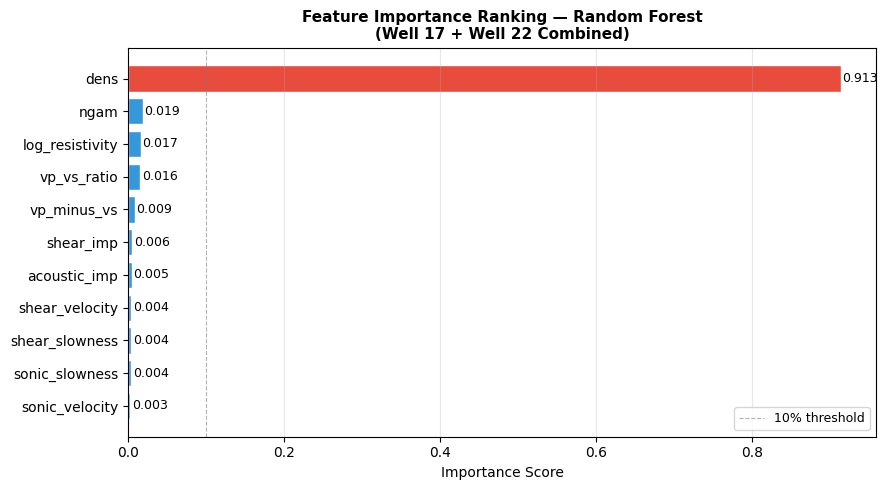

In [10]:
# Train a Random Forest on all data to get feature importances
# feature_importances_: measures how much each feature reduces prediction error
# across all trees; values sum to 1.0

rf_for_importance = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=RANDOM_STATE
)
rf_for_importance.fit(X_scaled, y)

importances = pd.Series(
    rf_for_importance.feature_importances_,
    index=FEATURES
).sort_values(ascending=False)

# Print importance table
print('Feature importance ranking (values sum to 1.0):')
for feat, imp in importances.items():
    bar = '█' * int(imp * 60)
    print(f'  {feat:<22} {imp:.4f}  {bar}')

# Plot feature importances
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v > 0.10 else '#3498db' for v in importances.values]
ax.barh(importances.index, importances.values, color=colors, edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=10)
ax.set_title(
    'Feature Importance Ranking — Random Forest\n'
    '(Well 17 + Well 22 Combined)',
    fontsize=11, fontweight='bold'
)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(0.10, color='gray', ls='--', lw=0.8, alpha=0.6, label='10% threshold')
for i, v in enumerate(importances.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Step 4 — Machine Learning Algorithms

We implement the four models from our methodology:

| Model | Approach | Strength |
|-------|----------|----------|
| XGBoost | Sequential gradient boosting | Best on tabular geoscience data |
| Random Forest | 200 independent decision trees, averaged | Robust, gives feature importance |
| Linear Regression | Fits a hyperplane through the data | Fast baseline, interpretable |
| Multi-layer Perceptron | Neural network with 65 hidden neurons | Captures non-linear patterns |

## Cell 12 — Define All Four Models

In [11]:
# ── XGBoost ──────────────────────────────────────────────────────────────────
# Sequential boosting: each new tree corrects the errors of the previous tree
# learning_rate controls how much each tree contributes (small = more careful)
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,          # Use 80% of data per tree — reduces overfitting
    colsample_bytree=0.8,   # Use 80% of features per tree
    random_state=RANDOM_STATE,
    verbosity=0
)

# ── Random Forest ─────────────────────────────────────────────────────────────
# Builds 200 independent trees on random subsets of data + features
# Final prediction = average of all 200 trees
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_split=5,    # Minimum samples to split a node — reduces overfitting
    max_features='sqrt',    # Use sqrt(n_features) per tree
    random_state=RANDOM_STATE
)

# ── Linear Regression ─────────────────────────────────────────────────────────
# Fits: GCV = w1*density + w2*GR + w3*res + ... + bias
# Assumes linear relationship between features and GCV
lr_model = LinearRegression()

# ── Multi-layer Perceptron ────────────────────────────────────────────────────
# Neural network: Input layer → 65 hidden neurons → Output (GCV)
# Logistic activation: σ(x) = 1 / (1 + e^{−x})
# alpha: L2 regularisation to prevent overfitting
mlp_model = MLPRegressor(
    hidden_layer_sizes=(65,),
    activation='logistic',
    solver='lbfgs',
    alpha=5,
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Collect all models in a dictionary for easy iteration
models = {
    'XGBoost':           xgb_model,
    'Random Forest':     rf_model,
    'Linear Regression': lr_model,
    'MLP':               mlp_model,
}

print('Models defined:')
for name in models:
    print(f'  {name}')

Models defined:
  XGBoost
  Random Forest
  Linear Regression
  MLP


---
# Step 5 — Model Training, Testing & Application

Two parallel tracks:
1. **Train & Test on XLSX data** — split into train/test, tune hyperparameters with GridSearchCV, evaluate with 5-fold cross-validation
2. **Apply to LAS files** — deploy the best model on continuous log data to predict GCV at every depth

## Cell 13 — Train/Test Split

In [12]:
# Split the XLSX lab dataset into training (80%) and test (20%) sets
# random_state ensures the same split every time (reproducible)
# stratify is not used because GCV is continuous, not categorical

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print('Train/test split:')
print(f'  Training set : {len(X_train)} samples ({len(X_train)/len(X_scaled)*100:.0f}%)')
print(f'  Test set     : {len(X_test)} samples ({len(X_test)/len(X_scaled)*100:.0f}%)')
print()
print(f'  Train GCV range: {y_train.min():.0f}–{y_train.max():.0f} Kcal/kg')
print(f'  Test  GCV range: {y_test.min():.0f}–{y_test.max():.0f} Kcal/kg')

Train/test split:
  Training set : 316 samples (80%)
  Test set     : 79 samples (20%)

  Train GCV range: -68–6030 Kcal/kg
  Test  GCV range: 364–5762 Kcal/kg


## Cell 14 — Hyperparameter Tuning with GridSearchCV

In [35]:
# GridSearchCV tries every combination of hyperparameters in the grid
# and selects the combination with the best cross-validated R² score
#
# We tune only the models where hyperparameters significantly affect performance
# Linear Regression has no hyperparameters to tune

print('Running GridSearchCV hyperparameter tuning...')
print('(This may take a few minutes)\n')

best_params = {}
kf_grid = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── XGBoost hyperparameter grid ──────────────────────────────────────────────
xgb_param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [4, 5, 6],
    'learning_rate': [0.05, 0.1],
}
xgb_grid = GridSearchCV(
    xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0,
                     subsample=0.8, colsample_bytree=0.8),
    xgb_param_grid,
    cv=kf_grid,
    scoring='r2',
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
best_params['XGBoost'] = xgb_grid.best_params_
print(f'XGBoost    best params: {xgb_grid.best_params_}  (R²={xgb_grid.best_score_:.4f})')

# ── Random Forest hyperparameter grid ────────────────────────────────────────
rf_param_grid = {
    'n_estimators':    [100, 200],
    'max_depth':       [6, 8, 10],
    'min_samples_split': [3, 5],
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, max_features='sqrt'),
    rf_param_grid,
    cv=kf_grid,
    scoring='r2',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_params['Random Forest'] = rf_grid.best_params_
print(f'Random Forest best params: {rf_grid.best_params_}  (R²={rf_grid.best_score_:.4f})')

# ── MLP hyperparameter grid ───────────────────────────────────────────────────
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (65,), (100,)],
    'alpha':              [1, 5, 10],
    'activation':         ['logistic', 'relu', 'tanh'],  
    'solver':             ['lbfgs', 'adam'],              
    'max_iter':           [500, 1000, 2000],             
}
mlp_grid = GridSearchCV(
    MLPRegressor(activation='logistic', solver='lbfgs',
                 max_iter=1000, random_state=RANDOM_STATE),
    mlp_param_grid,
    cv=kf_grid,
    scoring='r2',
    n_jobs=-1
)
mlp_grid.fit(X_train, y_train)
best_params['MLP'] = mlp_grid.best_params_
print(f'MLP        best params: {mlp_grid.best_params_}  (R²={mlp_grid.best_score_:.4f})')

# Update models with best hyperparameters
models['XGBoost']       = xgb_grid.best_estimator_
models['Random Forest'] = rf_grid.best_estimator_
models['MLP']           = mlp_grid.best_estimator_

print('\nModels updated with best hyperparameters.')

# ── Optimal Hyperparameters Summary Table ────────────────────────────────────
print()
print('=' * 72)
print('OPTIMAL HYPERPARAMETERS — GridSearchCV (5-Fold CV on Training Set)')
print('=' * 72)

# Collect all unique hyperparameter names across all models
all_param_names = []
for name, params in best_params.items():
    for p in params:
        if p not in all_param_names:
            all_param_names.append(p)

# Model display names and their grid search objects
grid_objects = {
    'XGBoost':       xgb_grid,
    'Random Forest': rf_grid,
    'MLP':           mlp_grid,
}

# Column widths
col_param  = 24   # hyperparameter name column
col_model  = 18   # each model column
model_list = ['XGBoost', 'Random Forest', 'MLP']

# Header row
header = f'{"Hyperparameter":<{col_param}}'
for m in model_list:
    header += f'{m:<{col_model}}'
print(header)
print('-' * (col_param + col_model * len(model_list)))

# One row per hyperparameter
for param in all_param_names:
    row = f'{param:<{col_param}}'
    for m in model_list:
        val = best_params[m].get(param, '—')   # '—' if model doesn't have this param
        row += f'{str(val):<{col_model}}'
    print(row)

print('-' * (col_param + col_model * len(model_list)))

# CV R² score row
r2_row = f'{"CV R² (best)":<{col_param}}'
for m, grid in grid_objects.items():
    r2_row += f'{grid.best_score_:.4f}{"": <{col_model - 6}}'
print(r2_row)

# Note: Linear Regression has no hyperparameters
print()
print('Note: Linear Regression has no hyperparameters to tune.')
print('      "—" indicates the hyperparameter does not apply to that model.')
print('=' * 72)

Running GridSearchCV hyperparameter tuning...
(This may take a few minutes)

XGBoost    best params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}  (R²=0.8266)
Random Forest best params: {'max_depth': 8, 'min_samples_split': 3, 'n_estimators': 200}  (R²=0.8125)
MLP        best params: {'activation': 'logistic', 'alpha': 10, 'hidden_layer_sizes': (50,), 'max_iter': 2000, 'solver': 'lbfgs'}  (R²=0.8281)

Models updated with best hyperparameters.

OPTIMAL HYPERPARAMETERS — GridSearchCV (5-Fold CV on Training Set)
Hyperparameter          XGBoost           Random Forest     MLP               
------------------------------------------------------------------------------
learning_rate           0.05              —                 —                 
max_depth               4                 8                 —                 
n_estimators            100               200               —                 
min_samples_split       —                 3                 —             

## Cell 15 — 5-Fold Cross Validation on Full Dataset

In [14]:
def compute_mape(y_true, y_pred):
    """
    Mean Absolute Percentage Error.
    MAPE = (1/n) × Σ |yi − yp| / |yi| × 100
    Returns a percentage value.
    """
    return np.mean(np.abs((y_true - y_pred) / y_true) * 100)

In [15]:
def run_chained_cv(combined_df, models_dict, kf, random_state=RANDOM_STATE):
    """
    Perform 5-fold cross-validated chained prediction:
      Stage 1  →  Ash          (inputs: dens, ngam, log_resistivity)
      Stage 2  →  Moisture     (inputs: Stage-1 features + ash_predicted)
      Stage 3  →  GCV          (inputs: all 11 log features + ash_predicted
                                        + moisture_predicted)
 
    Within each fold:
      - All three stages are trained on the same training indices and
        evaluated on the same held-out test indices.
      - Stage-2 training uses *out-of-fold* ash predictions on the training
        set (not leaking test-fold predictions), ensuring no information
        leakage between stages.
      - Similarly Stage-3 training uses out-of-fold ash AND moisture
        predictions on the training set.
 
    Parameters
    ----------
    combined_df  : pd.DataFrame — combined merged lab + LAS DataFrame
                   (must already contain derived features)
    models_dict  : dict — {model_name: estimator} (tuned models)
    kf           : KFold — configured cross-validator
    random_state : int
 
    Returns
    -------
    chain_cv     : dict  — per-model CV metrics for ash, moisture, GCV
    chain_oof    : dict  — per-model out-of-fold prediction arrays
                           keys: 'ash_pred', 'moisture_pred', 'gcv_pred'
    y_ash_all    : np.ndarray — lab Ash values aligned to OOF rows
    y_moist_all  : np.ndarray — lab Moisture values aligned to OOF rows
    y_gcv_all    : np.ndarray — lab GCV values aligned to OOF rows
    valid_idx    : np.ndarray — integer indices into combined_df used
    """
    from sklearn.base import clone
 
    # ── Build the base feature matrix for Stage 1 ────────────────────────────
    # Drop rows missing any required Stage-1 feature or lab target
    stage1_cols = FEATURES_ASH + ['ash', 'moisture', 'gcv'] + FEATURES_GCV_CHAIN
    # Include all features needed across stages, keeping only complete rows
    all_needed = list(set(FEATURES_ASH + FEATURES_GCV_CHAIN +
                          ['ash', 'moisture', 'gcv']))
    # Remove chain-output columns from "must have upfront" check
    # (ash_predicted, moisture_predicted are generated during the loop)
    base_cols = [c for c in all_needed
                 if c not in ('ash_predicted', 'moisture_predicted')]
    sub = combined_df[base_cols].dropna()
    valid_idx = sub.index.values  # integer positions in combined_df
 
    y_ash   = sub['ash'].values
    y_moist = sub['moisture'].values
    y_gcv   = sub['gcv'].values
 
    n = len(sub)
 
    chain_cv  = {}   # {model_name: {target: {metric: value}}}
    chain_oof = {}   # {model_name: {ash_pred, moisture_pred, gcv_pred}}
 
    for name, model in models_dict.items():
        print(f'\n  [{name}] chained CV …')
 
        # Storage for out-of-fold predictions across the three stages
        oof_ash   = np.full(n, np.nan)
        oof_moist = np.full(n, np.nan)
        oof_gcv   = np.full(n, np.nan)
 
        for fold_i, (tr, te) in enumerate(kf.split(sub)):
            # ── Scalers (fit on training split only) ─────────────────────────
            sc_ash   = StandardScaler()
            sc_moist = StandardScaler()
            sc_gcv   = StandardScaler()
 
            # ── STAGE 1 — Ash ─────────────────────────────────────────────────
            X1_tr = sc_ash.fit_transform(sub[FEATURES_ASH].values[tr])
            X1_te = sc_ash.transform(sub[FEATURES_ASH].values[te])
 
            m1 = clone(model)
            m1.fit(X1_tr, y_ash[tr])
 
            # OOF ash predictions (test fold)
            ash_te_pred = m1.predict(X1_te)
            oof_ash[te] = ash_te_pred
 
            # In-sample ash predictions for training set of Stage 2
            # Use cross_val_predict on the TRAINING fold only to avoid leakage
            # (inner 4-fold OOF within training fold)
            inner_kf = KFold(n_splits=4, shuffle=True, random_state=random_state)
            ash_tr_oof = cross_val_predict(
                clone(model), X1_tr, y_ash[tr], cv=inner_kf
            )
 
            # ── STAGE 2 — Moisture ────────────────────────────────────────────
            # Training features: log curves + leakage-free ash predictions
            ash_tr_col = ash_tr_oof.reshape(-1, 1)
            ash_te_col = ash_te_pred.reshape(-1, 1)
 
            X2_base_tr = sub[FEATURES_ASH].values[tr]   # dens, ngam, log_res
            X2_base_te = sub[FEATURES_ASH].values[te]
 
            X2_tr_raw = np.hstack([X2_base_tr, ash_tr_col])
            X2_te_raw = np.hstack([X2_base_te, ash_te_col])
 
            X2_tr = sc_moist.fit_transform(X2_tr_raw)
            X2_te = sc_moist.transform(X2_te_raw)
 
            m2 = clone(model)
            m2.fit(X2_tr, y_moist[tr])
 
            moist_te_pred = m2.predict(X2_te)
            oof_moist[te] = moist_te_pred
 
            # In-sample moisture predictions for training set of Stage 3
            moist_tr_oof = cross_val_predict(
                clone(model), X2_tr, y_moist[tr], cv=inner_kf
            )
 
            # ── STAGE 3 — GCV ─────────────────────────────────────────────────
            # Base log features (all 11, no lab ash/moisture)
            log_features_base = [c for c in FEATURES_GCV_CHAIN
                                  if c not in ('ash_predicted', 'moisture_predicted')]
 
            X3_base_tr = sub[log_features_base].values[tr]
            X3_base_te = sub[log_features_base].values[te]
 
            X3_tr_raw = np.hstack([X3_base_tr,
                                   ash_tr_oof.reshape(-1, 1),
                                   moist_tr_oof.reshape(-1, 1)])
            X3_te_raw = np.hstack([X3_base_te,
                                   ash_te_pred.reshape(-1, 1),
                                   moist_te_pred.reshape(-1, 1)])
 
            X3_tr = sc_gcv.fit_transform(X3_tr_raw)
            X3_te = sc_gcv.transform(X3_te_raw)
 
            m3 = clone(model)
            m3.fit(X3_tr, y_gcv[tr])
 
            oof_gcv[te] = m3.predict(X3_te)
 
        # ── Compute metrics from OOF arrays ──────────────────────────────────
        def metrics_dict(y_true, y_pred):
            return {
                'r2':   r2_score(y_true, y_pred),
                'mae':  mean_absolute_error(y_true, y_pred),
                'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
                'mape': compute_mape(y_true, y_pred),
            }
 
        chain_cv[name] = {
            'ash':      metrics_dict(y_ash,   oof_ash),
            'moisture': metrics_dict(y_moist, oof_moist),
            'gcv':      metrics_dict(y_gcv,   oof_gcv),
        }
        chain_oof[name] = {
            'ash_pred':      oof_ash,
            'moisture_pred': oof_moist,
            'gcv_pred':      oof_gcv,
        }
 
        # Print fold summary
        for tgt in ('ash', 'moisture', 'gcv'):
            m = chain_cv[name][tgt]
            unit = '%' if tgt in ('ash', 'moisture') else 'Kcal/kg'
            print(f'    {tgt:<10}  R²={m["r2"]:.4f}  MAE={m["mae"]:.2f} {unit}  '
                  f'RMSE={m["rmse"]:.2f}  MAPE={m["mape"]:.2f}%')
 
    return chain_cv, chain_oof, y_ash, y_moist, y_gcv, valid_idx
 

In [16]:
# 5-Fold Cross Validation
# shuffle=True: randomly assign rows to folds — avoids depth-order bias
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
fold_mapes  = {}  # Stored for ANOVA test later

print(f'{'Model':<22} {'R² (mean±std)':<20} {'MAE (Kcal/kg)':<16} {'RMSE':<10} {'MAPE%'}')
print('=' * 76)

for name, model in models.items():

    # R² across 5 folds
    r2_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='r2')

    # MAE — sklearn returns negative values for error metrics
    mae_scores = -cross_val_score(
        model, X_scaled, y, cv=kf, scoring='neg_mean_absolute_error'
    )

    # RMSE — square root of mean squared error
    rmse_scores = np.sqrt(-cross_val_score(
        model, X_scaled, y, cv=kf, scoring='neg_mean_squared_error'
    ))

    # Out-of-fold predictions for MAPE and parity plots
    y_pred_oof = cross_val_predict(model, X_scaled, y, cv=kf)
    mape_val   = compute_mape(y.values, y_pred_oof)

    # Compute per-fold MAPE for ANOVA
    fold_mape_list = []
    from sklearn.base import clone
    for train_idx, test_idx in kf.split(X_scaled):
        m_clone = clone(model)
        m_clone.fit(X_scaled[train_idx], y.values[train_idx])
        y_fold_pred = m_clone.predict(X_scaled[test_idx])
        fold_mape_list.append(
            compute_mape(y.values[test_idx], y_fold_pred)
        )
    fold_mapes[name] = fold_mape_list

    cv_results[name] = {
        'r2':      r2_scores.mean(),
        'r2_std':  r2_scores.std(),
        'mae':     mae_scores.mean(),
        'rmse':    rmse_scores.mean(),
        'mape':    mape_val,
        'y_pred':  y_pred_oof,
    }

    print(f'{name:<22} {r2_scores.mean():.4f} ± {r2_scores.std():.3f}   '
          f'{mae_scores.mean():.1f}           {rmse_scores.mean():.1f}    '
          f'{mape_val:.2f}')

print('=' * 76)
best_model_name = max(cv_results, key=lambda k: cv_results[k]['r2'])
print(f'\nBest model: {best_model_name}  '
      f'(R² = {cv_results[best_model_name]["r2"]:.4f})')

Model                  R² (mean±std)        MAE (Kcal/kg)    RMSE       MAPE%
XGBoost                0.8311 ± 0.026   390.2           511.5    19.03
Random Forest          0.8230 ± 0.013   408.3           526.6    23.10
Linear Regression      0.8233 ± 0.038   397.4           523.4    22.38
MLP                    0.8151 ± 0.032   412.8           534.6    18.91

Best model: XGBoost  (R² = 0.8311)


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CHAINED CV — run all four models through the three-stage chain
# ─────────────────────────────────────────────────────────────────────────────
print('\n')
print('═' * 76)
print('CHAINED PREDICTION — 5-FOLD CROSS VALIDATION')
print('Stage 1: Ash  (dens, ngam, log_res)')
print('Stage 2: Moisture  (dens, ngam, log_res, ash_predicted)')
print('Stage 3: GCV  (all 11 log features, ash_predicted, moisture_predicted)')
print('═' * 76)
 
chain_cv, chain_oof, y_ash_cv, y_moist_cv, y_gcv_cv, chain_valid_idx = \
    run_chained_cv(combined, models, kf, RANDOM_STATE)
 
# ── Print a consolidated chained CV summary table ────────────────────────────
print()
print('── Chained CV Summary ──────────────────────────────────────────────────')
for target, unit in [('ash', '%'), ('moisture', '%'), ('gcv', 'Kcal/kg')]:
    print(f'\n  Target: {target.upper()}')
    print(f'  {"Model":<22} {"R²":<10} {"MAE (" + unit + ")":<16} '
          f'{"RMSE":<10} {"MAPE%"}')
    print('  ' + '-' * 64)
    best_r2 = max(chain_cv[m][target]['r2'] for m in chain_cv)
    for name in chain_cv:
        m = chain_cv[name][target]
        flag = '  ← best' if abs(m['r2'] - best_r2) < 1e-9 else ''
        print(f'  {name:<22} {m["r2"]:.4f}    {m["mae"]:.2f}           '
              f'{m["rmse"]:.2f}    {m["mape"]:.2f}{flag}')
 
# Identify the best model for each chain stage (by R²)
best_chain_ash   = max(chain_cv, key=lambda k: chain_cv[k]['ash']['r2'])
best_chain_moist = max(chain_cv, key=lambda k: chain_cv[k]['moisture']['r2'])
best_chain_gcv   = max(chain_cv, key=lambda k: chain_cv[k]['gcv']['r2'])
print(f'\n  Best for Ash      : {best_chain_ash}  '
      f'(R²={chain_cv[best_chain_ash]["ash"]["r2"]:.4f})')
print(f'  Best for Moisture : {best_chain_moist}  '
      f'(R²={chain_cv[best_chain_moist]["moisture"]["r2"]:.4f})')
print(f'  Best for GCV      : {best_chain_gcv}  '
      f'(R²={chain_cv[best_chain_gcv]["gcv"]["r2"]:.4f})')
 



════════════════════════════════════════════════════════════════════════════
CHAINED PREDICTION — 5-FOLD CROSS VALIDATION
Stage 1: Ash  (dens, ngam, log_res)
Stage 2: Moisture  (dens, ngam, log_res, ash_predicted)
Stage 3: GCV  (all 11 log features, ash_predicted, moisture_predicted)
════════════════════════════════════════════════════════════════════════════

  [XGBoost] chained CV …
    ash         R²=0.8496  MAE=4.67 %  RMSE=6.15  MAPE=10.99%
    moisture    R²=0.4121  MAE=1.57 %  RMSE=2.03  MAPE=30.21%
    gcv         R²=0.8375  MAE=386.56 Kcal/kg  RMSE=507.78  MAPE=18.67%

  [Random Forest] chained CV …
    ash         R²=0.8370  MAE=4.87 %  RMSE=6.41  MAPE=11.83%
    moisture    R²=0.4188  MAE=1.59 %  RMSE=2.02  MAPE=30.51%
    gcv         R²=0.8467  MAE=373.45 Kcal/kg  RMSE=493.22  MAPE=17.39%

  [Linear Regression] chained CV …
    ash         R²=0.8507  MAE=4.53 %  RMSE=6.13  MAPE=10.48%
    moisture    R²=0.4211  MAE=1.62 %  RMSE=2.02  MAPE=32.32%
    gcv         R²=0.8372 

## Cell 16 — Evaluate on Hold-Out Test Set

In [33]:
# Evaluate all models on the hold-out test set (20% of lab data)
# Models are trained on the training set only, then applied to unseen test data

print('Hold-out test set evaluation (20% of lab data):')
print(f'{'Model':<22} {'R²':<10} {'MAE':<12} {'RMSE':<12} {'MAPE%'}')
print('-' * 62)

test_results = {}

for name, model in models.items():
    # Train on training set
    model.fit(X_train, y_train)

    # Predict on test set
    y_pred_test = model.predict(X_test)

    r2   = r2_score(y_test, y_pred_test)
    mae  = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mape = compute_mape(y_test.values, y_pred_test)

    test_results[name] = {
        'r2': r2, 'mae': mae, 'rmse': rmse, 'mape': mape
    }

    print(f'{name:<22} {r2:.4f}    {mae:.1f}       {rmse:.1f}       {mape:.2f}')

print('-' * 62)
best_test = max(test_results, key=lambda k: test_results[k]['r2'])
print(f'Best on test set: {best_test}  R²={test_results[best_test]["r2"]:.4f}')

Hold-out test set evaluation (20% of lab data):
Model                  R²         MAE          RMSE         MAPE%
--------------------------------------------------------------
XGBoost                0.8444    364.0       467.5       15.46
Random Forest          0.8321    383.9       485.5       19.61
Linear Regression      0.8574    350.3       447.5       14.15
MLP                    0.8088    410.2       518.3       16.39
--------------------------------------------------------------
Best on test set: Linear Regression  R²=0.8574


# CELL 18 - EVALUATE ON CHAINED MODEL HOLD OUT TEST SET

In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CHAINED HOLD-OUT TEST SET EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
print()
print('── Chained Hold-out Test Set Evaluation (20% of lab data) ─────────────')
 
# Rebuild the chained dataset subset (same as inside run_chained_cv)
base_cols_test = [c for c in
                  list(set(FEATURES_ASH + FEATURES_GCV_CHAIN +
                           ['ash', 'moisture', 'gcv']))
                  if c not in ('ash_predicted', 'moisture_predicted')]
sub_chain = combined[base_cols_test].dropna().reset_index(drop=True)
 
y_ash_all   = sub_chain['ash'].values
y_moist_all = sub_chain['moisture'].values
y_gcv_all   = sub_chain['gcv'].values
log_feats_base = [c for c in FEATURES_GCV_CHAIN
                  if c not in ('ash_predicted', 'moisture_predicted')]
 
# 80 / 20 split (same random_state for reproducibility)
idx_all = np.arange(len(sub_chain))
idx_tr, idx_te = train_test_split(idx_all, test_size=0.20,
                                  random_state=RANDOM_STATE)
 
chain_test_results = {}
for name, model in models.items():
    from sklearn.base import clone
 
    # ── Stage 1 — Ash ────────────────────────────────────────────────────────
    sc1 = StandardScaler()
    X1_tr = sc1.fit_transform(sub_chain[FEATURES_ASH].values[idx_tr])
    X1_te = sc1.transform(sub_chain[FEATURES_ASH].values[idx_te])
    m1 = clone(model); m1.fit(X1_tr, y_ash_all[idx_tr])
    ash_te = m1.predict(X1_te)
    ash_tr = m1.predict(X1_tr)   # used as input to Stage 2 training
 
    # ── Stage 2 — Moisture ───────────────────────────────────────────────────
    sc2 = StandardScaler()
    X2_tr_raw = np.hstack([sub_chain[FEATURES_ASH].values[idx_tr],
                            ash_tr.reshape(-1, 1)])
    X2_te_raw = np.hstack([sub_chain[FEATURES_ASH].values[idx_te],
                            ash_te.reshape(-1, 1)])
    X2_tr = sc2.fit_transform(X2_tr_raw)
    X2_te = sc2.transform(X2_te_raw)
    m2 = clone(model); m2.fit(X2_tr, y_moist_all[idx_tr])
    moist_te = m2.predict(X2_te)
    moist_tr = m2.predict(X2_tr)
 
    # ── Stage 3 — GCV ────────────────────────────────────────────────────────
    sc3 = StandardScaler()
    X3_tr_raw = np.hstack([sub_chain[log_feats_base].values[idx_tr],
                            ash_tr.reshape(-1, 1),
                            moist_tr.reshape(-1, 1)])
    X3_te_raw = np.hstack([sub_chain[log_feats_base].values[idx_te],
                            ash_te.reshape(-1, 1),
                            moist_te.reshape(-1, 1)])
    X3_tr = sc3.fit_transform(X3_tr_raw)
    X3_te = sc3.transform(X3_te_raw)
    m3 = clone(model); m3.fit(X3_tr, y_gcv_all[idx_tr])
    gcv_te = m3.predict(X3_te)
 
    chain_test_results[name] = {
        'ash':      {'r2': r2_score(y_ash_all[idx_te], ash_te),
                     'mae': mean_absolute_error(y_ash_all[idx_te], ash_te),
                     'rmse': np.sqrt(mean_squared_error(y_ash_all[idx_te], ash_te)),
                     'mape': compute_mape(y_ash_all[idx_te], ash_te)},
        'moisture': {'r2': r2_score(y_moist_all[idx_te], moist_te),
                     'mae': mean_absolute_error(y_moist_all[idx_te], moist_te),
                     'rmse': np.sqrt(mean_squared_error(y_moist_all[idx_te], moist_te)),
                     'mape': compute_mape(y_moist_all[idx_te], moist_te)},
        'gcv':      {'r2': r2_score(y_gcv_all[idx_te], gcv_te),
                     'mae': mean_absolute_error(y_gcv_all[idx_te], gcv_te),
                     'rmse': np.sqrt(mean_squared_error(y_gcv_all[idx_te], gcv_te)),
                     'mape': compute_mape(y_gcv_all[idx_te], gcv_te)},
        'ash_pred_te':   ash_te,
        'moist_pred_te': moist_te,
        'gcv_pred_te':   gcv_te,
        'ash_true_te':   y_ash_all[idx_te],
        'moist_true_te': y_moist_all[idx_te],
        'gcv_true_te':   y_gcv_all[idx_te],
    }
 
for target, unit in [('ash', '%'), ('moisture', '%'), ('gcv', 'Kcal/kg')]:
    print(f'\n  Target: {target.upper()}  (hold-out test)')
    print(f'  {"Model":<22} {"R²":<10} {"MAE (" + unit + ")":<16} '
          f'{"RMSE":<10} {"MAPE%"}')
    print('  ' + '-' * 64)
    for name in chain_test_results:
        m = chain_test_results[name][target]
        print(f'  {name:<22} {m["r2"]:.4f}    {m["mae"]:.2f}           '
              f'{m["rmse"]:.2f}    {m["mape"]:.2f}')
 


── Chained Hold-out Test Set Evaluation (20% of lab data) ─────────────

  Target: ASH  (hold-out test)
  Model                  R²         MAE (%)          RMSE       MAPE%
  ----------------------------------------------------------------
  XGBoost                0.8601    4.26           5.55    9.28
  Random Forest          0.8305    4.63           6.11    10.03
  Linear Regression      0.8701    3.99           5.35    8.83
  MLP                    0.8739    3.82           5.27    8.30

  Target: MOISTURE  (hold-out test)
  Model                  R²         MAE (%)          RMSE       MAPE%
  ----------------------------------------------------------------
  XGBoost                0.3744    1.44           1.74    31.58
  Random Forest          0.4092    1.37           1.69    29.93
  Linear Regression      0.3369    1.45           1.79    33.24
  MLP                    0.3824    1.36           1.73    31.41

  Target: GCV  (hold-out test)
  Model                  R²         MAE (Kc

## Cell 17 — Model Validation: Train on All Data, Apply to LAS Files

In [20]:
def apply_model_to_las(las_df, fitted_scaler, fitted_model):
    """
    Apply a trained model to all valid depth points in a LAS DataFrame.

    Steps:
    1. Compute derived features (same formulas as training)
    2. Extract feature columns, drop rows with NaN
    3. Scale using the SAME scaler fitted on training data (.transform only)
    4. Predict GCV at every valid depth
    5. Store predictions back in the DataFrame

    Parameters
    ----------
    las_df        : pd.DataFrame — LAS DataFrame (raw, from load_las_file)
    fitted_scaler : StandardScaler — fitted on training data
    fitted_model  : trained model — already fitted on combined lab data

    Returns
    -------
    pd.DataFrame — LAS DataFrame with 'gcv_predicted' and 'grade' columns added
    """
    df = las_df.copy()

    # Add derived features (same formulas as training)
    df['vp_vs_ratio']    = df['sonic_velocity'] / df['shear_velocity'].replace(0, np.nan)
    df['acoustic_imp']   = df['dens'] * df['sonic_velocity']
    df['shear_imp']      = df['dens'] * df['shear_velocity']
    df['vp_minus_vs']    = df['sonic_velocity'] - df['shear_velocity']
    df['log_resistivity']= np.log1p(df['res'])

    # Rename LAS columns to match training feature names
    df.rename(columns={
        'sonic_velocity': 'sonic_velocity',
        'shear_velocity': 'shear_velocity',
        'sonic_slowness': 'sonic_slowness',
        'shear_slowness': 'shear_slowness',
    }, inplace=True)

    # Map LAS curve names to feature names
    las_to_feature = {
        'dens': 'dens',
        'ngam': 'ngam',
        'log_resistivity': 'log_resistivity',
        'sonic_velocity':  'sonic_velocity',
        'shear_velocity':  'shear_velocity',
        'sonic_slowness':  'sonic_slowness',
        'shear_slowness':  'shear_slowness',
        'vp_vs_ratio':     'vp_vs_ratio',
        'acoustic_imp':    'acoustic_imp',
        'shear_imp':       'shear_imp',
        'vp_minus_vs':     'vp_minus_vs',
    }

    # Extract feature columns and drop rows with any missing values
    X_las = df[FEATURES].dropna()
    valid_idx = X_las.index

    # Scale using the SAME scaler from training — do NOT re-fit
    X_las_scaled = fitted_scaler.transform(X_las)

    # Predict GCV at all valid depths
    gcv_predicted = fitted_model.predict(X_las_scaled)

    # Store predictions back in the DataFrame
    df.loc[valid_idx, 'gcv_predicted'] = gcv_predicted

    return df

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CHAINED LAS PREDICTION
# Apply the chained pipeline to full LAS files:
#   Stage 1  →  ash_predicted  at every 0.1 m depth
#   Stage 2  →  moisture_predicted  (uses ash_predicted)
#   Stage 3  →  gcv_predicted_chain  (uses ash_predicted + moisture_predicted)
# ─────────────────────────────────────────────────────────────────────────────
 
def apply_chained_model_to_las(las_df, stage1_model, stage1_scaler,
                                stage2_model, stage2_scaler,
                                stage3_model, stage3_scaler):
    """
    Apply the trained three-stage chained model to a full LAS DataFrame.
 
    Applies derived features first, then runs:
      Stage 1: predict Ash from log curves
      Stage 2: predict Moisture from log curves + predicted Ash
      Stage 3: predict GCV from all log features + predicted Ash + predicted Moisture
 
    Parameters
    ----------
    las_df          : pd.DataFrame — raw LAS DataFrame
    stage*_model    : fitted estimator for each stage
    stage*_scaler   : StandardScaler fitted for each stage on lab training data
 
    Returns
    -------
    pd.DataFrame — LAS DataFrame with three new columns:
                   'ash_predicted', 'moisture_predicted', 'gcv_predicted_chain'
    """
    df = las_df.copy()
    # Derived features — same formulas as training
    df['vp_vs_ratio']     = df['sonic_velocity'] / df['shear_velocity'].replace(0, np.nan)
    df['acoustic_imp']    = df['dens'] * df['sonic_velocity']
    df['shear_imp']       = df['dens'] * df['shear_velocity']
    df['vp_minus_vs']     = df['sonic_velocity'] - df['shear_velocity']
    df['log_resistivity'] = np.log1p(df['res'])
 
    log_feats_base = [c for c in FEATURES_GCV_CHAIN
                      if c not in ('ash_predicted', 'moisture_predicted')]
 
    # Valid rows must have all log features (no NaN in any column used)
    all_log_cols = list(set(FEATURES_ASH + log_feats_base))
    valid_mask = df[all_log_cols].notna().all(axis=1)
    valid_idx  = df[valid_mask].index
 
    # ── Stage 1 — Ash ────────────────────────────────────────────────────────
    X1 = stage1_scaler.transform(df.loc[valid_idx, FEATURES_ASH].values)
    ash_pred = stage1_model.predict(X1)
    df.loc[valid_idx, 'ash_predicted'] = ash_pred
 
    # ── Stage 2 — Moisture ───────────────────────────────────────────────────
    X2_raw = np.hstack([df.loc[valid_idx, FEATURES_ASH].values,
                        ash_pred.reshape(-1, 1)])
    X2 = stage2_scaler.transform(X2_raw)
    moist_pred = stage2_model.predict(X2)
    df.loc[valid_idx, 'moisture_predicted'] = moist_pred
 
    # ── Stage 3 — GCV ────────────────────────────────────────────────────────
    X3_raw = np.hstack([df.loc[valid_idx, log_feats_base].values,
                        ash_pred.reshape(-1, 1),
                        moist_pred.reshape(-1, 1)])
    X3 = stage3_scaler.transform(X3_raw)
    gcv_pred = stage3_model.predict(X3)
    df.loc[valid_idx, 'gcv_predicted_chain'] = gcv_pred
 
    return df
 
 
# Train the three-stage chained models on ALL available lab data
# (both wells combined) — for the best possible LAS-wide prediction
print('\nTraining final chained models on all combined lab data …')
 
best_chain_model_name = best_chain_gcv   # use best GCV-chain model for LAS output
 
from sklearn.base import clone
log_feats_base_final = [c for c in FEATURES_GCV_CHAIN
                        if c not in ('ash_predicted', 'moisture_predicted')]
 
# Sub-dataset for chaining (same as in run_chained_cv)
base_cols_final = [c for c in
                   list(set(FEATURES_ASH + FEATURES_GCV_CHAIN +
                             ['ash', 'moisture', 'gcv']))
                   if c not in ('ash_predicted', 'moisture_predicted')]
sub_final = combined[base_cols_final].dropna().reset_index(drop=True)
 
# ── Stage 1 scaler & model ───────────────────────────────────────────────────
sc_final_1 = StandardScaler()
X1_final   = sc_final_1.fit_transform(sub_final[FEATURES_ASH].values)
m1_final   = clone(models[best_chain_model_name])
m1_final.fit(X1_final, sub_final['ash'].values)
ash_final_pred = m1_final.predict(X1_final)
 
# ── Stage 2 scaler & model ───────────────────────────────────────────────────
sc_final_2 = StandardScaler()
X2_final_raw = np.hstack([sub_final[FEATURES_ASH].values,
                            ash_final_pred.reshape(-1, 1)])
X2_final   = sc_final_2.fit_transform(X2_final_raw)
m2_final   = clone(models[best_chain_model_name])
m2_final.fit(X2_final, sub_final['moisture'].values)
moist_final_pred = m2_final.predict(X2_final)
 
# ── Stage 3 scaler & model ───────────────────────────────────────────────────
sc_final_3 = StandardScaler()
X3_final_raw = np.hstack([sub_final[log_feats_base_final].values,
                            ash_final_pred.reshape(-1, 1),
                            moist_final_pred.reshape(-1, 1)])
X3_final   = sc_final_3.fit_transform(X3_final_raw)
m3_final   = clone(models[best_chain_model_name])
m3_final.fit(X3_final, sub_final['gcv'].values)
 
print(f'  Stage 1 (Ash)      — trained on {len(sub_final)} samples')
print(f'  Stage 2 (Moisture) — trained on {len(sub_final)} samples')
print(f'  Stage 3 (GCV)      — trained on {len(sub_final)} samples')
print(f'  Model used: {best_chain_model_name}')
 
# Apply chained pipeline to full LAS files
pred_las_well17_chain = apply_chained_model_to_las(
    las_well17,
    m1_final, sc_final_1,
    m2_final, sc_final_2,
    m3_final, sc_final_3
)
pred_las_well22_chain = apply_chained_model_to_las(
    las_well22,
    m1_final, sc_final_1,
    m2_final, sc_final_2,
    m3_final, sc_final_3
)
 
print(f'\nWell 17 (chained) — GCV predicted at '
      f'{pred_las_well17_chain["gcv_predicted_chain"].notna().sum()} depth points')
print(f'  Ash range     : '
      f'{pred_las_well17_chain["ash_predicted"].dropna().min():.1f}–'
      f'{pred_las_well17_chain["ash_predicted"].dropna().max():.1f} %')
print(f'  Moisture range: '
      f'{pred_las_well17_chain["moisture_predicted"].dropna().min():.1f}–'
      f'{pred_las_well17_chain["moisture_predicted"].dropna().max():.1f} %')
print(f'  GCV range     : '
      f'{pred_las_well17_chain["gcv_predicted_chain"].dropna().min():.0f}–'
      f'{pred_las_well17_chain["gcv_predicted_chain"].dropna().max():.0f} Kcal/kg')
 
print(f'\nWell 22 (chained) — GCV predicted at '
      f'{pred_las_well22_chain["gcv_predicted_chain"].notna().sum()} depth points')
print(f'  Ash range     : '
      f'{pred_las_well22_chain["ash_predicted"].dropna().min():.1f}–'
      f'{pred_las_well22_chain["ash_predicted"].dropna().max():.1f} %')
print(f'  Moisture range: '
      f'{pred_las_well22_chain["moisture_predicted"].dropna().min():.1f}–'
      f'{pred_las_well22_chain["moisture_predicted"].dropna().max():.1f} %')
print(f'  GCV range     : '
      f'{pred_las_well22_chain["gcv_predicted_chain"].dropna().min():.0f}–'
      f'{pred_las_well22_chain["gcv_predicted_chain"].dropna().max():.0f} Kcal/kg')


Training final chained models on all combined lab data …
  Stage 1 (Ash)      — trained on 395 samples
  Stage 2 (Moisture) — trained on 395 samples
  Stage 3 (GCV)      — trained on 395 samples
  Model used: Random Forest

Well 17 (chained) — GCV predicted at 5561 depth points
  Ash range     : 20.6–80.1 %
  Moisture range: 1.5–11.7 %
  GCV range     : 383–5686 Kcal/kg

Well 22 (chained) — GCV predicted at 26986 depth points
  Ash range     : 18.4–80.8 %
  Moisture range: 1.5–13.7 %
  GCV range     : 232–5585 Kcal/kg


In [22]:
# Train the best model on ALL available lab data (both wells combined)
# We use all data now — not just training split — for the best possible model
best_model = models[best_model_name]
best_model.fit(X_scaled, y)
print(f'Final model ({best_model_name}) trained on all {len(y)} combined samples.')

# Apply to both full LAS files
pred_las_well17 = apply_model_to_las(las_well17, scaler, best_model)
pred_las_well22 = apply_model_to_las(las_well22, scaler, best_model)

print(f'\nWell 17 — GCV predicted at {pred_las_well17["gcv_predicted"].notna().sum()} depth points')
print(f'  Predicted range: {pred_las_well17["gcv_predicted"].dropna().min():.0f}–'
      f'{pred_las_well17["gcv_predicted"].dropna().max():.0f} Kcal/kg')
print(f'Well 22 — GCV predicted at {pred_las_well22["gcv_predicted"].notna().sum()} depth points')
print(f'  Predicted range: {pred_las_well22["gcv_predicted"].dropna().min():.0f}–'
      f'{pred_las_well22["gcv_predicted"].dropna().max():.0f} Kcal/kg')

Final model (XGBoost) trained on all 395 combined samples.

Well 17 — GCV predicted at 5561 depth points
  Predicted range: 468–5437 Kcal/kg
Well 22 — GCV predicted at 26895 depth points
  Predicted range: 425–5636 Kcal/kg


---
# Step 6 — Model Evaluation & Comparison

We evaluate all four models using:
- **MAE** — Mean Absolute Error (Kcal/kg)
- **RMSE** — Root Mean Square Error (Kcal/kg)
- **MAPE** — Mean Absolute Percentage Error (%)
- **R²** — Coefficient of determination
- **Other Metrics** — ISP 2022 coal grade comparison, parity plots, GCV log plots

## Cell 18 — Model Comparison Bar Charts

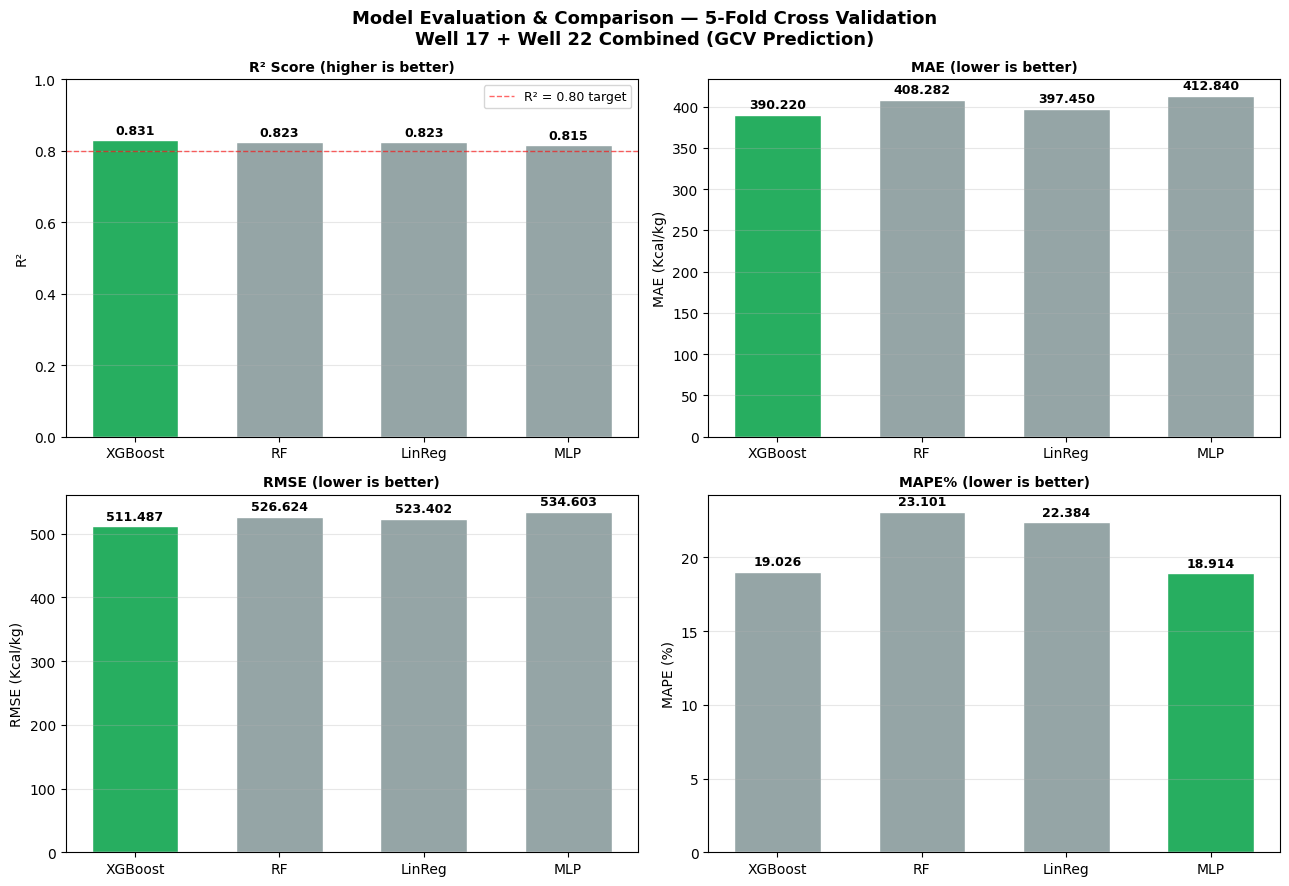

Saved: model_comparison.png


In [23]:
# Plot all four evaluation metrics side by side for all models

model_names  = list(cv_results.keys())
short_names  = ['XGBoost', 'RF', 'LinReg', 'MLP']
r2_vals      = [cv_results[m]['r2']   for m in model_names]
mae_vals     = [cv_results[m]['mae']  for m in model_names]
rmse_vals    = [cv_results[m]['rmse'] for m in model_names]
mape_vals    = [cv_results[m]['mape'] for m in model_names]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    'Model Evaluation & Comparison — 5-Fold Cross Validation\n'
    'Well 17 + Well 22 Combined (GCV Prediction)',
    fontsize=13, fontweight='bold'
)

metrics = [
    (axes[0, 0], r2_vals,   'R²',         'R² Score (higher is better)',  False),
    (axes[0, 1], mae_vals,  'MAE (Kcal/kg)', 'MAE (lower is better)',     True),
    (axes[1, 0], rmse_vals, 'RMSE (Kcal/kg)','RMSE (lower is better)',    True),
    (axes[1, 1], mape_vals, 'MAPE (%)',    'MAPE% (lower is better)',      True),
]

for ax, vals, ylabel, title, lower_is_better in metrics:
    best_val = min(vals) if lower_is_better else max(vals)
    bar_colors = ['#27ae60' if v == best_val else '#95a5a6' for v in vals]
    bars = ax.bar(range(len(model_names)), vals, color=bar_colors,
                  edgecolor='white', width=0.6)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(short_names, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(vals):
        ax.text(i, v + max(vals) * 0.02, f'{v:.3f}',
                ha='center', fontsize=9, fontweight='bold')

# Add R² = 0.80 reference line on R² plot
axes[0, 0].axhline(0.80, color='red', ls='--', lw=1, alpha=0.6,
                   label='R² = 0.80 target')
axes[0, 0].set_ylim(0, 1.0)
axes[0, 0].legend(fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

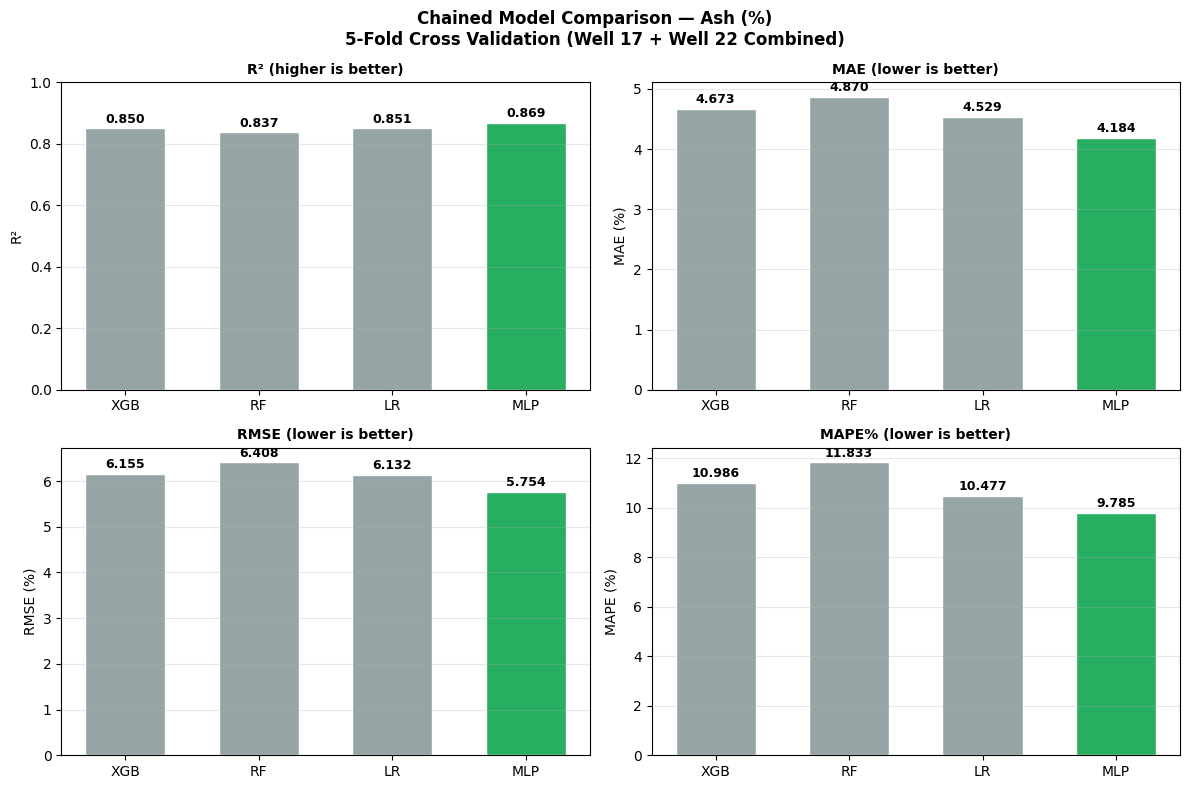

Saved: chained_model_comparison_ash.png


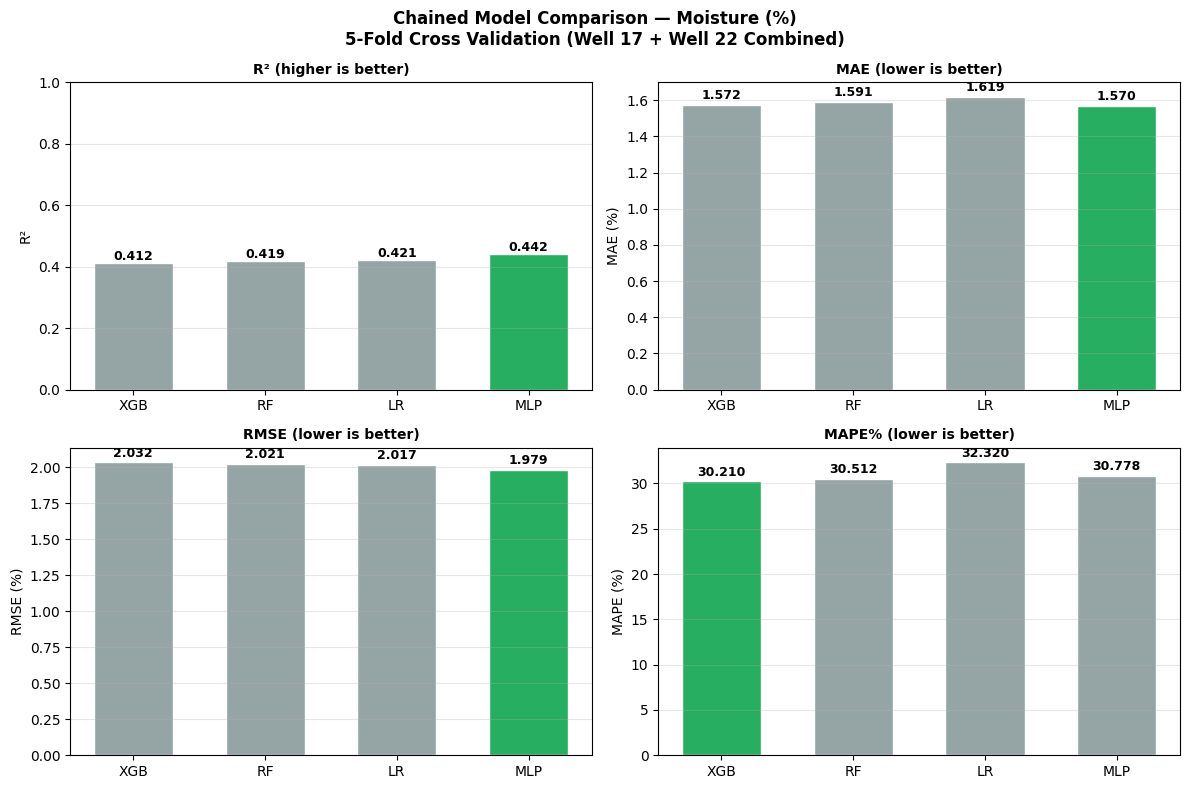

Saved: chained_model_comparison_moisture.png


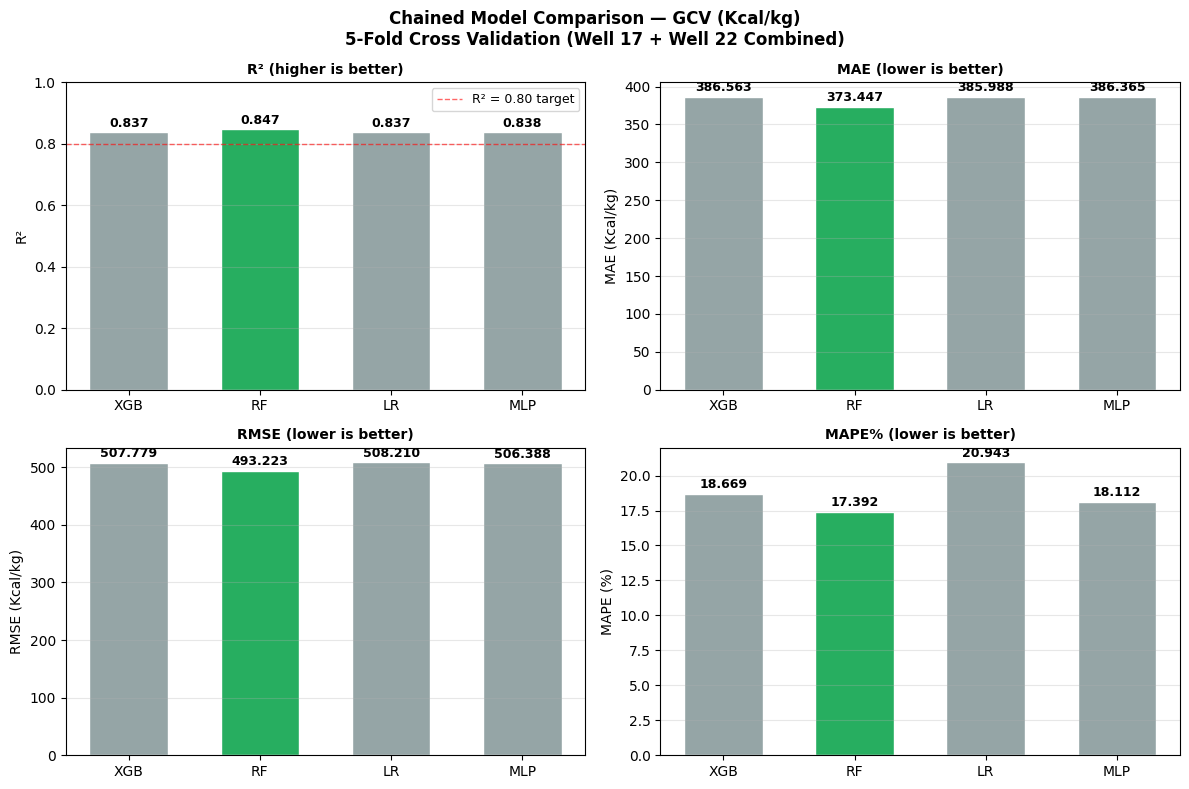

Saved: chained_model_comparison_gcv.png


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CHAINED MODEL COMPARISON PLOT
# One 2×2 panel per target (Ash, Moisture, GCV) showing R², MAE, RMSE, MAPE
# ─────────────────────────────────────────────────────────────────────────────
chain_model_names = list(chain_cv.keys())
chain_short       = ['XGB', 'RF', 'LR', 'MLP']
 
for target, unit, title_lbl in [
    ('ash',      '%',        'Ash (%)'),
    ('moisture', '%',        'Moisture (%)'),
    ('gcv',      'Kcal/kg',  'GCV (Kcal/kg)'),
]:
    r2v   = [chain_cv[m][target]['r2']   for m in chain_model_names]
    maev  = [chain_cv[m][target]['mae']  for m in chain_model_names]
    rmse_v= [chain_cv[m][target]['rmse'] for m in chain_model_names]
    mapev = [chain_cv[m][target]['mape'] for m in chain_model_names]
 
    fig2, axes2 = plt.subplots(2, 2, figsize=(12, 8))
    fig2.suptitle(
        f'Chained Model Comparison — {title_lbl}\n'
        '5-Fold Cross Validation (Well 17 + Well 22 Combined)',
        fontsize=12, fontweight='bold'
    )
    metrics2 = [
        (axes2[0, 0], r2v,    'R²',           'R² (higher is better)',  False),
        (axes2[0, 1], maev,   f'MAE ({unit})', f'MAE (lower is better)', True),
        (axes2[1, 0], rmse_v, f'RMSE ({unit})','RMSE (lower is better)', True),
        (axes2[1, 1], mapev,  'MAPE (%)',      'MAPE% (lower is better)',True),
    ]
    for ax2, vals2, ylabel2, ttl2, lib2 in metrics2:
        best_v = min(vals2) if lib2 else max(vals2)
        cols2  = ['#27ae60' if v == best_v else '#95a5a6' for v in vals2]
        ax2.bar(range(len(chain_model_names)), vals2, color=cols2,
                edgecolor='white', width=0.6)
        ax2.set_xticks(range(len(chain_model_names)))
        ax2.set_xticklabels(chain_short, fontsize=10)
        ax2.set_ylabel(ylabel2, fontsize=10)
        ax2.set_title(ttl2, fontsize=10, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        for i2, v2 in enumerate(vals2):
            ax2.text(i2, v2 + max(vals2) * 0.02, f'{v2:.3f}',
                     ha='center', fontsize=9, fontweight='bold')
    if target == 'gcv':
        axes2[0, 0].axhline(0.80, color='red', ls='--', lw=1, alpha=0.6,
                            label='R² = 0.80 target')
        axes2[0, 0].legend(fontsize=9)
    axes2[0, 0].set_ylim(0, max(1.0, max(r2v) * 1.1))
    plt.tight_layout()
    fname = f'chained_model_comparison_{target}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## Cell 19 — Parity Plots (Predicted vs Actual GCV)

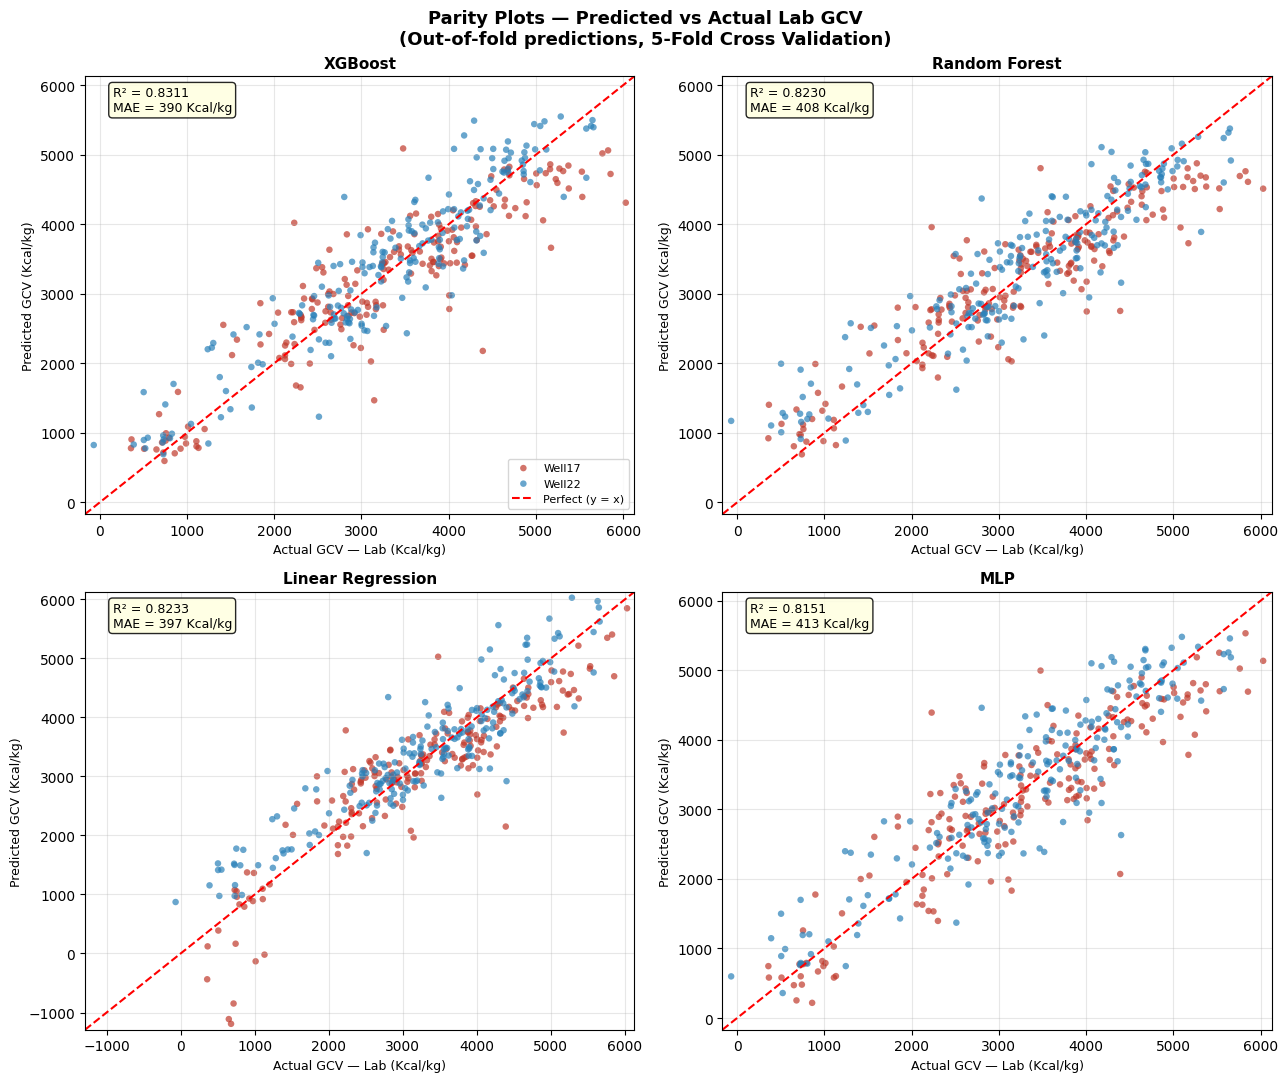

Saved: parity_plots.png


In [25]:
# Parity plot: predicted vs actual GCV
# Points on the y = x line = perfect prediction
# Points above = overprediction, below = underprediction
# Color-coded by well to show cross-well generalisation

well_colors = {'Well17': '#c0392b', 'Well22': '#2980b9'}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle(
    'Parity Plots — Predicted vs Actual Lab GCV\n'
    '(Out-of-fold predictions, 5-Fold Cross Validation)',
    fontsize=13, fontweight='bold'
)

for ax, name in zip(axes.flat, model_names):
    res     = cv_results[name]
    y_pred  = res['y_pred']

    # Plot each well with a different colour
    for wname, wcolor in well_colors.items():
        mask = (well_labels == wname).values
        ax.scatter(
            y[mask], y_pred[mask],
            c=wcolor, s=22, alpha=0.7,
            label=wname, edgecolors='none'
        )

    # Perfect prediction reference line: y = x
    lims = [
        min(y.min(), y_pred.min()) - 100,
        max(y.max(), y_pred.max()) + 100
    ]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect (y = x)')
    ax.set_xlim(lims); ax.set_ylim(lims)

    ax.set_xlabel('Actual GCV — Lab (Kcal/kg)', fontsize=9)
    ax.set_ylabel('Predicted GCV (Kcal/kg)', fontsize=9)
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Annotate with R² and MAE
    ax.text(
        0.05, 0.92,
        f"R² = {res['r2']:.4f}\nMAE = {res['mae']:.0f} Kcal/kg",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85)
    )

    if name == model_names[0]:
        ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('parity_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: parity_plots.png')

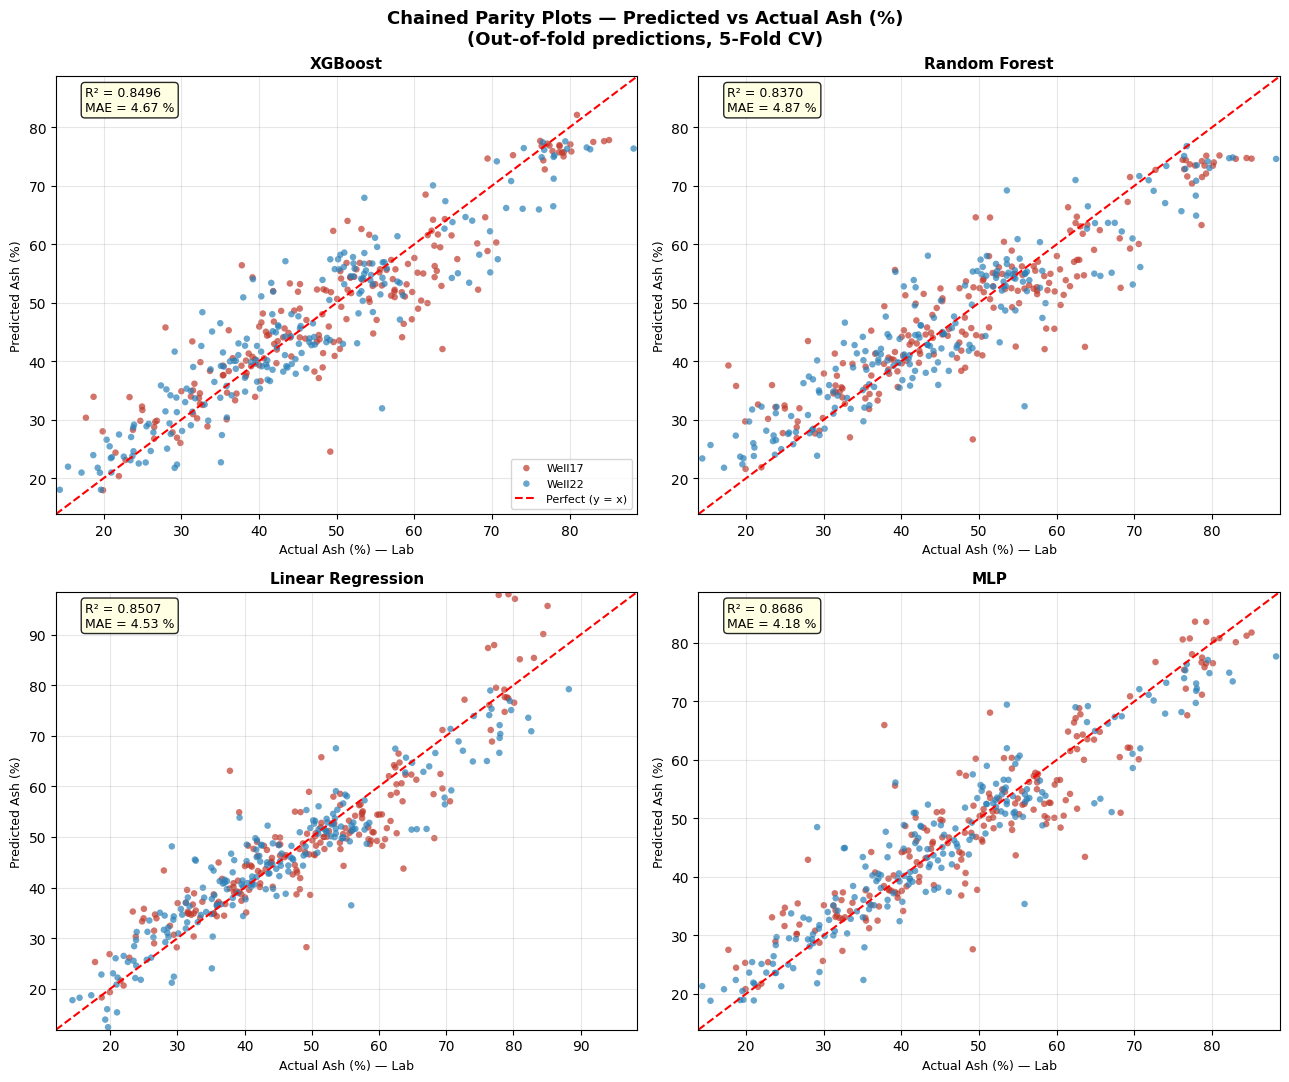

Saved: chained_parity_ash.png


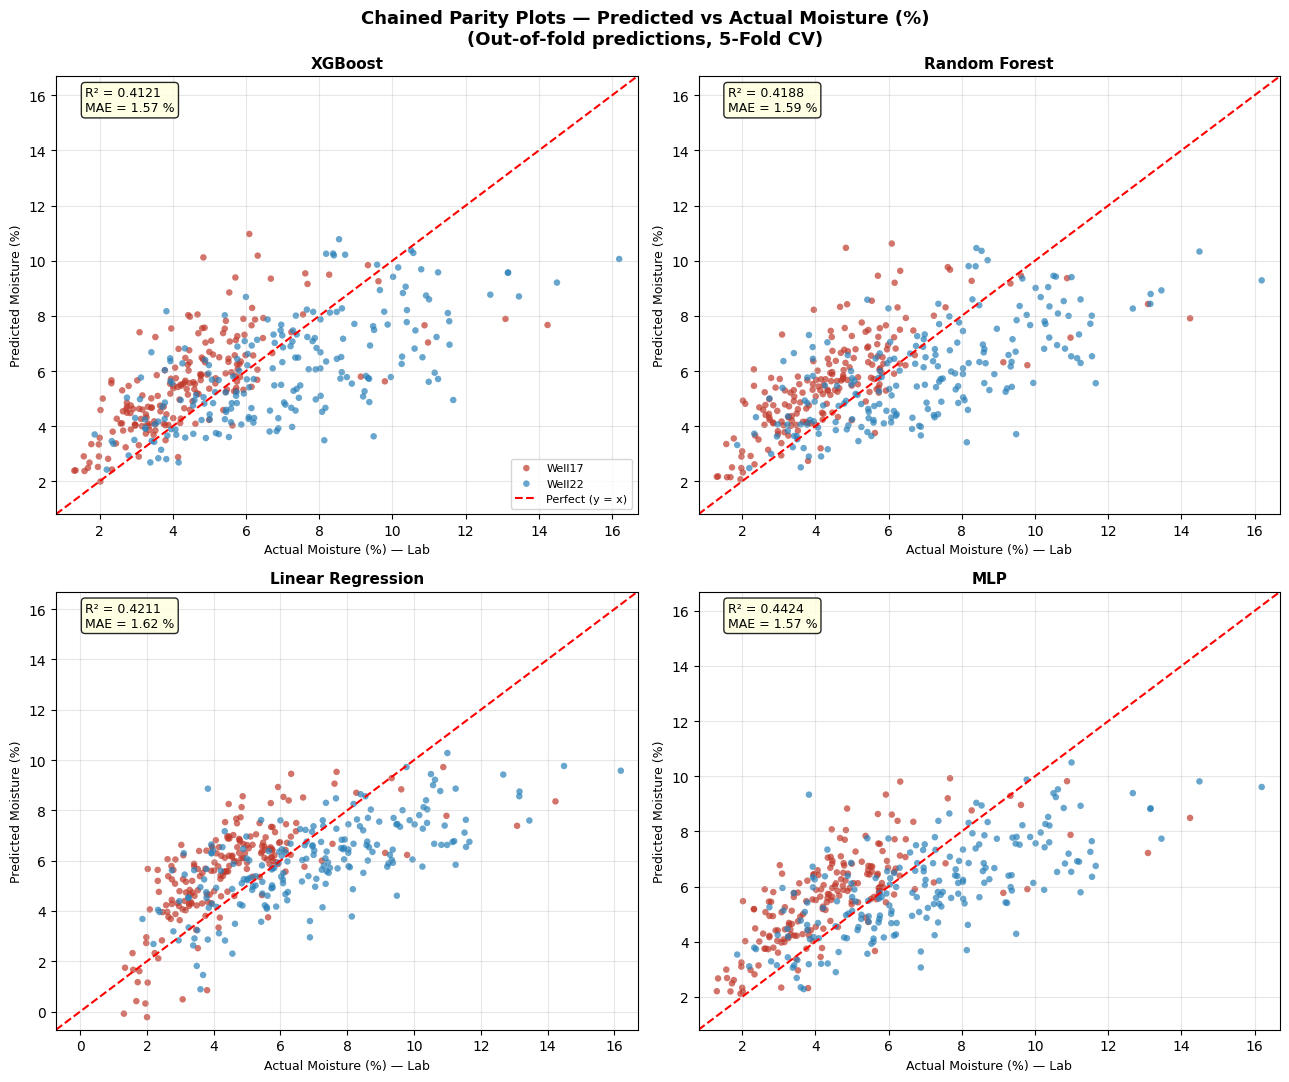

Saved: chained_parity_moisture.png


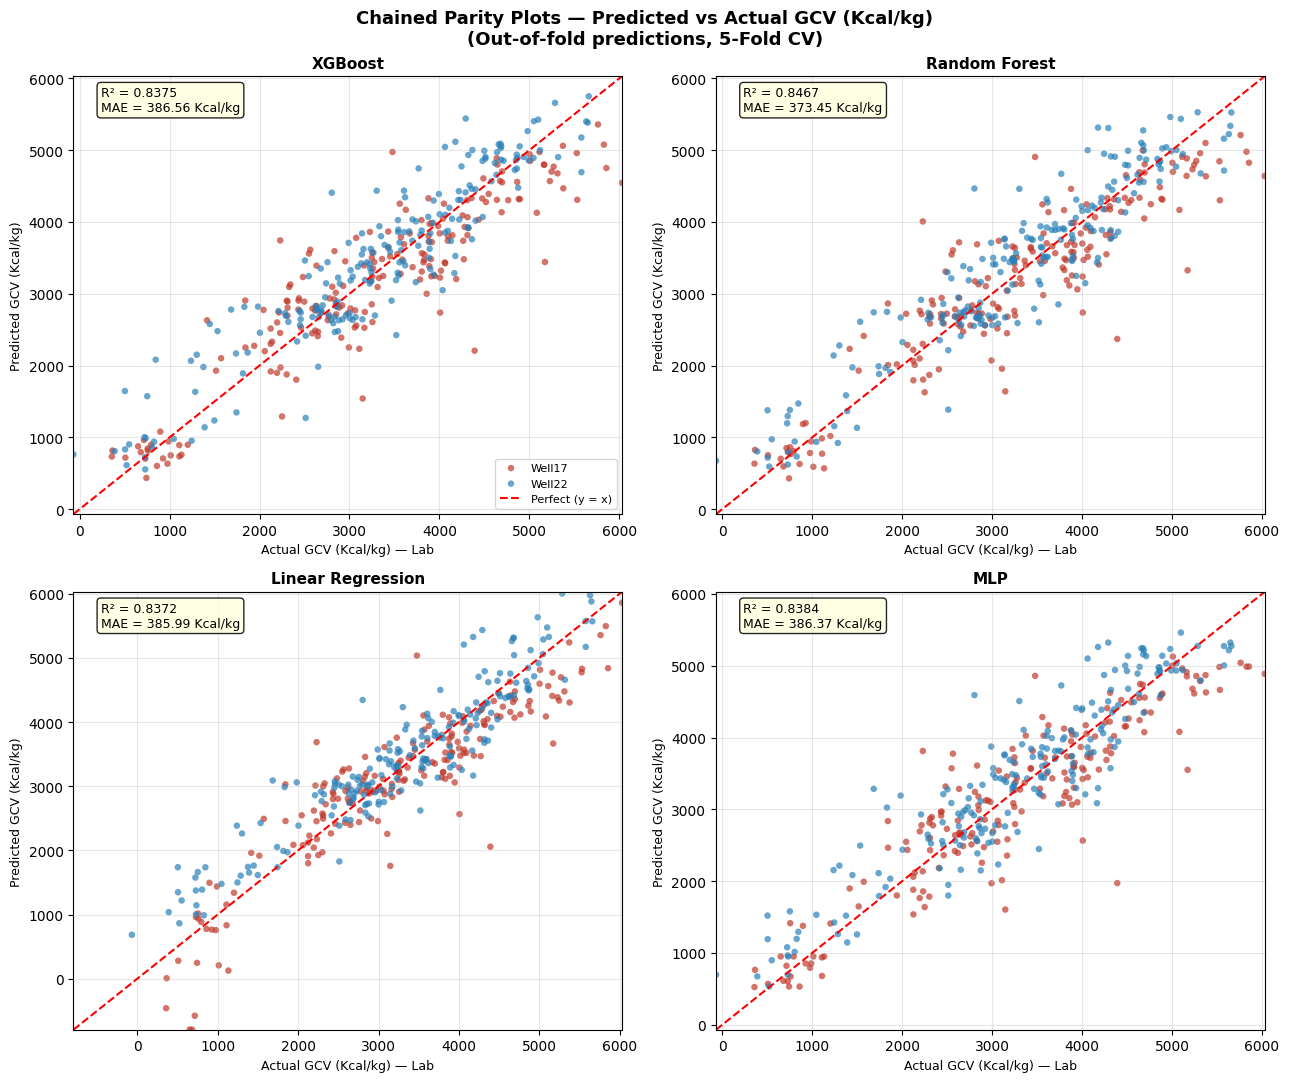

Saved: chained_parity_gcv.png


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# CHAINED PARITY PLOTS — Ash, Moisture, GCV (OOF, all four models)
# ─────────────────────────────────────────────────────────────────────────────
chain_well_labels = combined.loc[chain_valid_idx, 'well'].values
 
for target, unit, title_lbl in [
    ('ash',      '%',        'Ash (%)'),
    ('moisture', '%',        'Moisture (%)'),
    ('gcv',      'Kcal/kg',  'GCV (Kcal/kg)'),
]:
    y_true_chain = (y_ash_cv   if target == 'ash'
                    else y_moist_cv if target == 'moisture'
                    else y_gcv_cv)
 
    fig3, axes3 = plt.subplots(2, 2, figsize=(13, 11))
    fig3.suptitle(
        f'Chained Parity Plots — Predicted vs Actual {title_lbl}\n'
        '(Out-of-fold predictions, 5-Fold CV)',
        fontsize=13, fontweight='bold'
    )
    for ax3, name in zip(axes3.flat, chain_cv.keys()):
        y_pred_chain = chain_oof[name][f'{target}_pred']
        r2_c  = chain_cv[name][target]['r2']
        mae_c = chain_cv[name][target]['mae']
 
        for wname, wcolor in well_colors.items():
            wmask = (chain_well_labels == wname)
            ax3.scatter(y_true_chain[wmask], y_pred_chain[wmask],
                        c=wcolor, s=22, alpha=0.7, label=wname, edgecolors='none')
 
        lims3 = [min(y_true_chain.min(), y_pred_chain.min()) - 0.5,
                 max(y_true_chain.max(), y_pred_chain.max()) + 0.5]
        ax3.plot(lims3, lims3, 'r--', lw=1.5, label='Perfect (y = x)')
        ax3.set_xlim(lims3); ax3.set_ylim(lims3)
        ax3.set_xlabel(f'Actual {title_lbl} — Lab', fontsize=9)
        ax3.set_ylabel(f'Predicted {title_lbl}', fontsize=9)
        ax3.set_title(name, fontsize=11, fontweight='bold')
        ax3.grid(True, alpha=0.3)
        ax3.text(0.05, 0.92,
                 f'R² = {r2_c:.4f}\nMAE = {mae_c:.2f} {unit}',
                 transform=ax3.transAxes, fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))
        if name == list(chain_cv.keys())[0]:
            ax3.legend(fontsize=8, loc='lower right')
 
    plt.tight_layout()
    fname3 = f'chained_parity_{target}.png'
    plt.savefig(fname3, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname3}')
 

## Cell 20 — Predicted GCV Log Plots (Well 17 & Well 22)

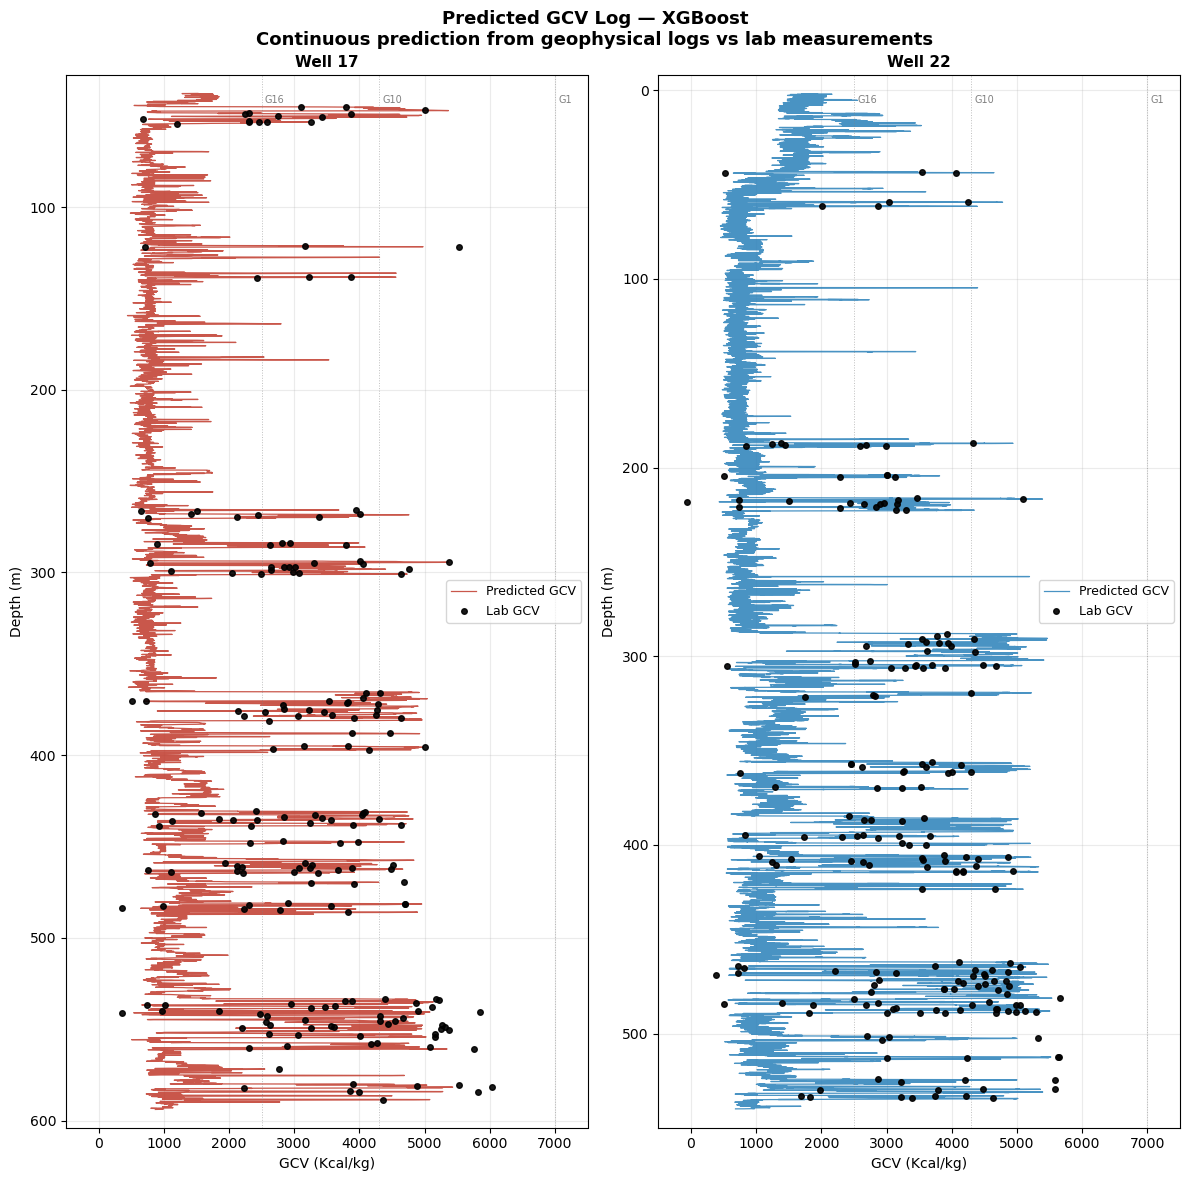

Saved: gcv_predicted_logs.png


In [20]:
# Plot predicted GCV as a continuous log alongside lab GCV points
# This is the key deliverable: continuous GCV at every 0.1 m

fig, axes = plt.subplots(1, 2, figsize=(12, 12))
fig.suptitle(
    f'Predicted GCV Log — {best_model_name}\n'
    'Continuous prediction from geophysical logs vs lab measurements',
    fontsize=13, fontweight='bold'
)

plot_config = [
    (axes[0], pred_las_well17, lab_well17, '#c0392b', 'Well 17'),
    (axes[1], pred_las_well22, lab_well22, '#2980b9', 'Well 22'),
]

for ax, pred_df, lab_df, color, wlabel in plot_config:
    gcv_log = pred_df[['dept', 'gcv_predicted']].dropna()

    # Continuous predicted GCV log (line)
    ax.plot(
        gcv_log['gcv_predicted'], gcv_log['dept'],
        color=color, lw=0.9, alpha=0.85, label='Predicted GCV'
    )

    # Lab-measured GCV points (scatter)
    ax.scatter(
        lab_df['gcv'], lab_df['depth'],
        c='black', s=16, zorder=5, label='Lab GCV', alpha=0.9
    )

    # Depth axis: increasing downward (geological convention)
    ax.set_ylim(gcv_log['dept'].max() + 10, gcv_log['dept'].min() - 10)
    ax.set_xlim(-500, 7500)
    ax.set_xlabel('GCV (Kcal/kg)', fontsize=10)
    ax.set_ylabel('Depth (m)', fontsize=10)
    ax.set_title(wlabel, fontsize=11, fontweight='bold')

    # Grade reference lines
    for gcv_val, label in [(7000, 'G1'), (4300, 'G10'), (2500, 'G16')]:
        ax.axvline(gcv_val, color='gray', ls=':', lw=0.7, alpha=0.5)
        ax.text(gcv_val + 50, gcv_log['dept'].min() + 5, label,
                fontsize=7, color='gray')

    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('gcv_predicted_logs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gcv_predicted_logs.png')

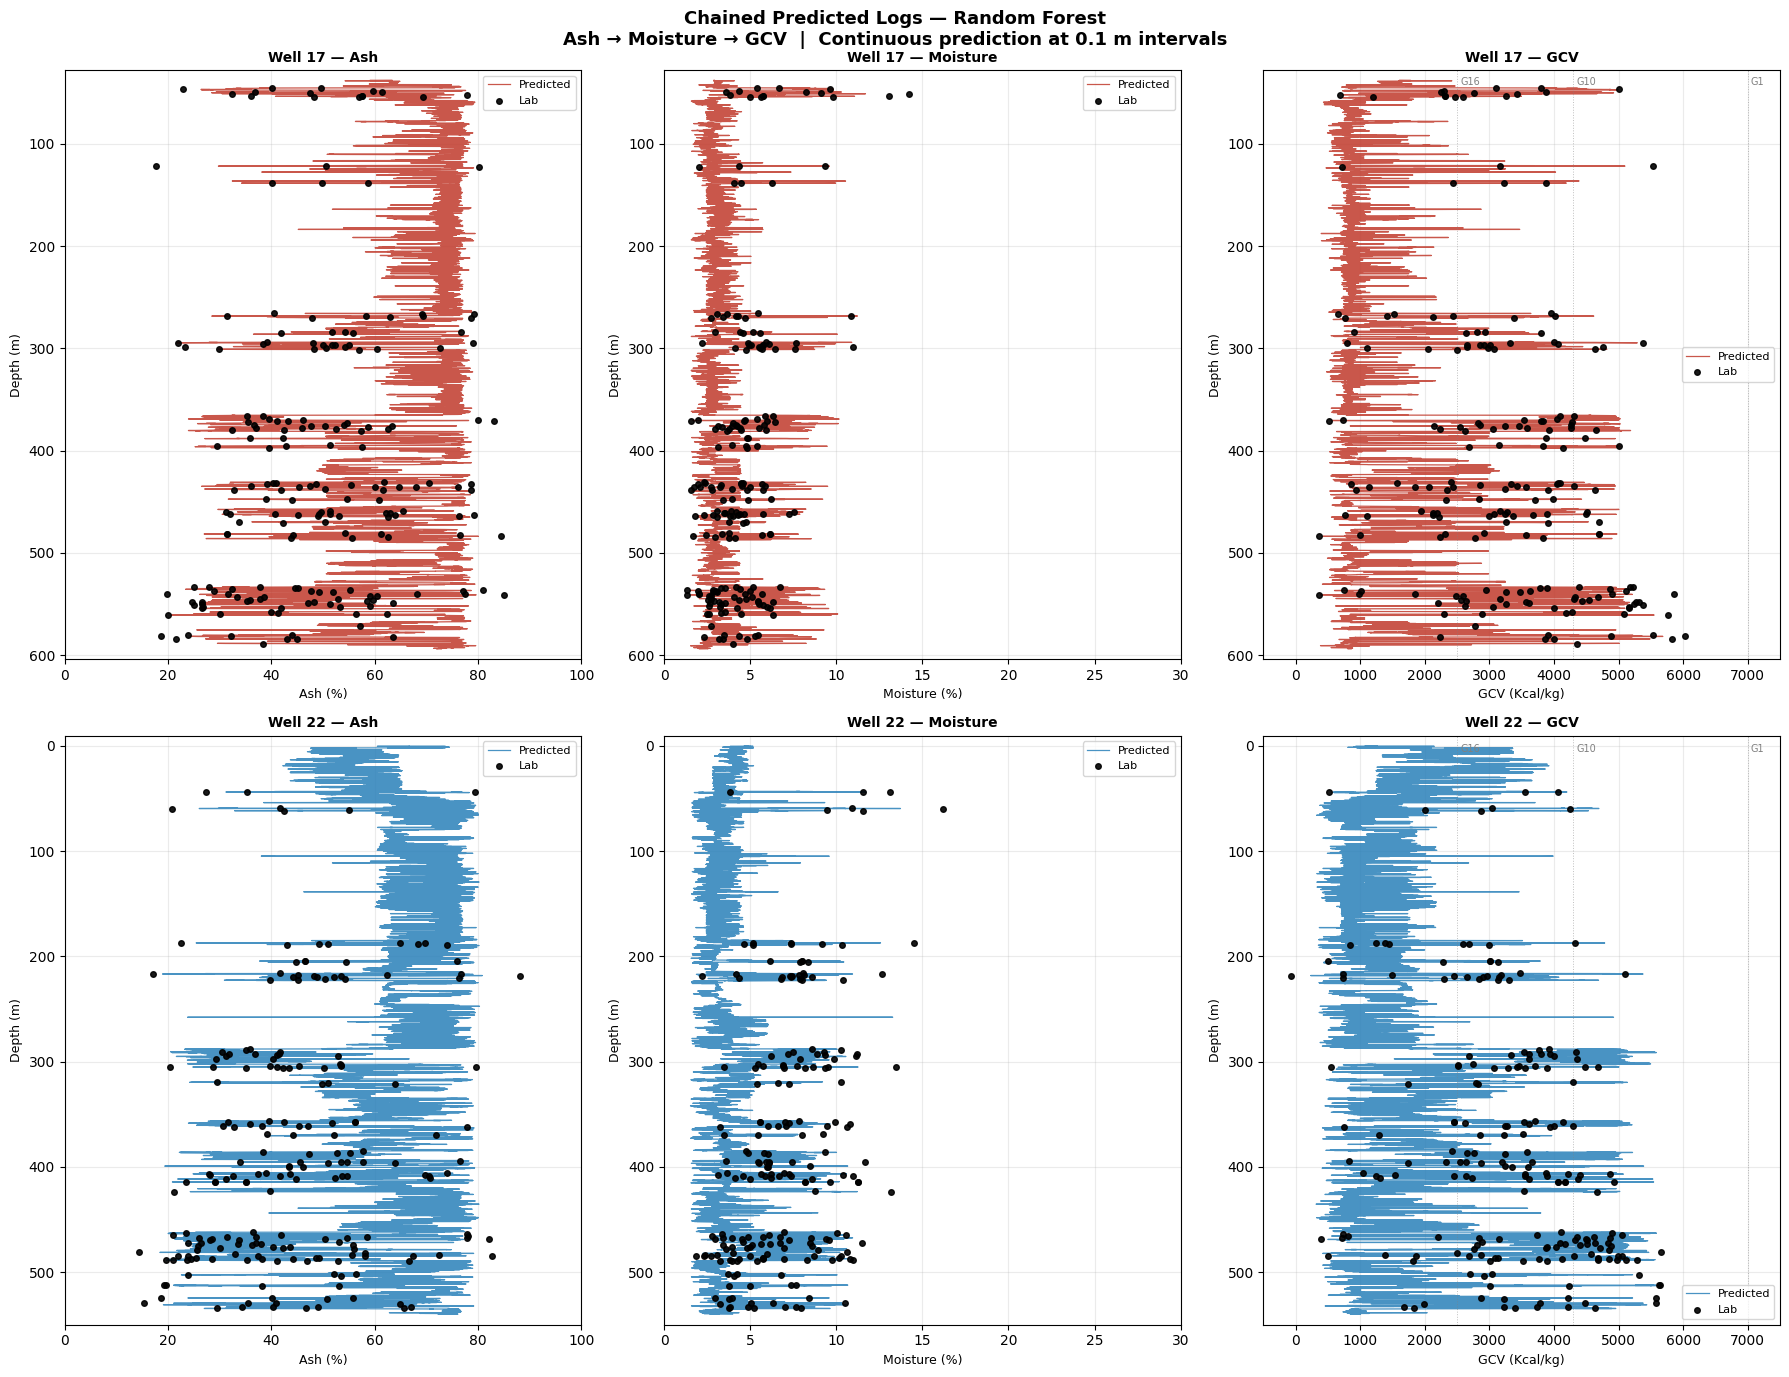

Saved: chained_predicted_logs.png


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# CHAINED GCV LOG PLOT — Ash, Moisture and GCV side by side
# ─────────────────────────────────────────────────────────────────────────────
fig4, axes4 = plt.subplots(2, 3, figsize=(18, 14))
fig4.suptitle(
    f'Chained Predicted Logs — {best_chain_model_name}\n'
    'Ash → Moisture → GCV  |  Continuous prediction at 0.1 m intervals',
    fontsize=13, fontweight='bold'
)
chain_plot_cfg = [
    (axes4[0, 0], pred_las_well17_chain, lab_well17, '#c0392b', 'Well 17 — Ash',
     'ash_predicted', 'ash', 'Ash (%)', (0, 100)),
    (axes4[0, 1], pred_las_well17_chain, lab_well17, '#c0392b', 'Well 17 — Moisture',
     'moisture_predicted', 'moisture', 'Moisture (%)', (0, 30)),
    (axes4[0, 2], pred_las_well17_chain, lab_well17, '#c0392b', 'Well 17 — GCV',
     'gcv_predicted_chain', 'gcv', 'GCV (Kcal/kg)', (-500, 7500)),
    (axes4[1, 0], pred_las_well22_chain, lab_well22, '#2980b9', 'Well 22 — Ash',
     'ash_predicted', 'ash', 'Ash (%)', (0, 100)),
    (axes4[1, 1], pred_las_well22_chain, lab_well22, '#2980b9', 'Well 22 — Moisture',
     'moisture_predicted', 'moisture', 'Moisture (%)', (0, 30)),
    (axes4[1, 2], pred_las_well22_chain, lab_well22, '#2980b9', 'Well 22 — GCV',
     'gcv_predicted_chain', 'gcv', 'GCV (Kcal/kg)', (-500, 7500)),
]
for ax4, pred_df4, lab_df4, col4, ttl4, pred_col, lab_col, xlabel4, xlim4 \
        in chain_plot_cfg:
    log_data = pred_df4[['dept', pred_col]].dropna()
    ax4.plot(log_data[pred_col], log_data['dept'],
             color=col4, lw=0.9, alpha=0.85, label=f'Predicted')
    ax4.scatter(lab_df4[lab_col], lab_df4['depth'],
                c='black', s=16, zorder=5, label='Lab', alpha=0.9)
    ax4.set_ylim(log_data['dept'].max() + 10, log_data['dept'].min() - 10)
    ax4.set_xlim(xlim4)
    ax4.set_xlabel(xlabel4, fontsize=9)
    ax4.set_ylabel('Depth (m)', fontsize=9)
    ax4.set_title(ttl4, fontsize=10, fontweight='bold')
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.25)
    # GCV grade lines
    if pred_col == 'gcv_predicted_chain':
        for gcv_val, glabel in [(7000, 'G1'), (4300, 'G10'), (2500, 'G16')]:
            ax4.axvline(gcv_val, color='gray', ls=':', lw=0.7, alpha=0.5)
            ax4.text(gcv_val + 50, log_data['dept'].min() + 5, glabel,
                     fontsize=7, color='gray')
plt.tight_layout()
plt.savefig('chained_predicted_logs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chained_predicted_logs.png')

## Cell 21 — ISP 2022 Coal Grade Classification (Other Metrics)

In [29]:
def classify_gcv_grade(gcv):
    """
    Classify GCV (Kcal/kg) into ISP 2022 non-coking coal grade.

    Source: Indian Standard Procedures (ISP) 2022, Table 6.
    Grades G1 (best, GCV > 7000) to G17 (lowest, GCV < 2500).

    Parameters
    ----------
    gcv : float — Gross Calorific Value in Kcal/kg

    Returns
    -------
    str — ISP 2022 grade (e.g. 'G7', 'G10', 'G14')
    """
    thresholds = [
        (7000, 'G1'),  (6700, 'G2'),  (6400, 'G3'),  (6100, 'G4'),
        (5800, 'G5'),  (5500, 'G6'),  (5200, 'G7'),  (4900, 'G8'),
        (4600, 'G9'),  (4300, 'G10'), (4000, 'G11'), (3700, 'G12'),
        (3400, 'G13'), (3100, 'G14'), (2800, 'G15'), (2500, 'G16'),
    ]
    for thresh, grade in thresholds:
        if gcv >= thresh:
            return grade
    return 'G17'


# Apply grading to lab data
lab_well17['grade'] = lab_well17['gcv'].apply(classify_gcv_grade)
lab_well22['grade'] = lab_well22['gcv'].apply(classify_gcv_grade)

# Apply grading to predicted GCV on LAS
pred_las_well17['grade'] = pred_las_well17['gcv_predicted'].dropna().apply(classify_gcv_grade)
pred_las_well22['grade'] = pred_las_well22['gcv_predicted'].dropna().apply(classify_gcv_grade)

# Apply grading to chained predictions
pred_las_well17_chain['grade_chain'] = (
    pred_las_well17_chain['gcv_predicted_chain'].dropna().apply(classify_gcv_grade)
)
pred_las_well22_chain['grade_chain'] = (
    pred_las_well22_chain['gcv_predicted_chain'].dropna().apply(classify_gcv_grade)
)

print('ISP 2022 coal grade distribution — Lab data:')
print()
print('Well 17 (coal + shaly coal only):')
coal_mask_17 = lab_well17['lithology'].isin(['COAL', 'SHALY COAL'])
print(lab_well17[coal_mask_17]['grade'].value_counts().sort_index())

print()
print('Well 22 (coal + shaly coal only):')
coal_mask_22 = lab_well22['lithology'].isin(['COAL', 'SHALY COAL'])
print(lab_well22[coal_mask_22]['grade'].value_counts().sort_index())

print()
print('Predicted grade distribution (full LAS — all depths):')
print('Well 17:')
print(pred_las_well17['grade'].value_counts().sort_index())
print('Well 22:')
print(pred_las_well22['grade'].value_counts().sort_index())
print()
print('Predicted grade distribution (full LAS — chained model):')
print('Well 17:')
print(pred_las_well17_chain['grade_chain'].value_counts().sort_index())
print('Well 22:')
print(pred_las_well22_chain['grade_chain'].value_counts().sort_index())

ISP 2022 coal grade distribution — Lab data:

Well 17 (coal + shaly coal only):
grade
G10    11
G11    16
G12    20
G13    12
G14    15
G15     1
G5      3
G6      3
G7      6
G8      7
G9     11
Name: count, dtype: int64

Well 22 (coal + shaly coal only):
grade
G10    15
G11    19
G12    17
G13    20
G14    18
G15     6
G6      5
G7      2
G8      7
G9     16
Name: count, dtype: int64

Predicted grade distribution (full LAS — all depths):
Well 17:
grade
G10     109
G11      80
G12      90
G13     103
G14      40
G15      45
G16     102
G17    4811
G7        8
G8       45
G9      128
Name: count, dtype: int64
Well 22:
grade
G10      273
G11      281
G12      440
G13      466
G14      303
G15      237
G16      700
G17    22491
G6         4
G7       191
G8       637
G9       872
Name: count, dtype: int64

Predicted grade distribution (full LAS — chained model):
Well 17:
grade_chain
G10      98
G11      74
G12      92
G13     108
G14      71
G15      89
G16     205
G17    4630
G6        3

## Cell 22 — Final Summary Table

In [30]:
# Print a clean summary table for inclusion in the technical report

print('=' * 76)
print('FINAL RESULTS SUMMARY — Bhoomathon GCV Prediction Pipeline')
print('=' * 76)
print()
print('Dataset:')
print(f'  Wells              : Well 17 + Well 22')
print(f'  Total lab samples  : {len(X)} (W17={len(merged_well17)}, W22={len(merged_well22)})')
print(f'  Features used      : {len(FEATURES)}')
print(f'  GCV range          : {y.min():.0f}–{y.max():.0f} Kcal/kg')
print()
print('5-Fold Cross Validation Results:')
print(f'  {"Model":<22} {"R²":<10} {"MAE Kcal/kg":<14} {"RMSE":<10} {"MAPE%"}')
print('  ' + '-' * 60)
for name in model_names:
    r  = cv_results[name]
    flag = '  <-- best' if name == best_model_name else ''
    print(f'  {name:<22} {r["r2"]:.4f}    {r["mae"]:.1f}         '
          f'{r["rmse"]:.1f}     {r["mape"]:.2f}{flag}')
print()
print('5-Fold Cross Validation Results (CHAINED):')
for target, unit in [('ash', '%'), ('moisture', '%'), ('gcv', 'Kcal/kg')]:
    print(f'\n  Target: {target.upper()} ({unit})')
    print(f'  {"Model":<22} {"R²":<10} {"MAE":<14} {"RMSE":<10} {"MAPE%"}')
    print('  ' + '-' * 60)
    best_r2_chain = max(chain_cv[m][target]['r2'] for m in chain_cv)
    for name in chain_cv:
        m = chain_cv[name][target]
        flag = '  <-- best' if abs(m['r2'] - best_r2_chain) < 1e-9 else ''
        print(f'  {name:<22} {m["r2"]:.4f}    {m["mae"]:.2f}         '
              f'{m["rmse"]:.2f}     {m["mape"]:.2f}{flag}')
print()
print('Libraries used:')
print(f'  Python {3}, pandas {pd.__version__}, numpy {np.__version__}')
print(f'  lasio {lasio.__version__}, scikit-learn {sklearn.__version__}, xgboost {xgb.__version__}')
print()
print('Outputs generated:')
print('  correlation_matrix.png')
print('  feature_importance.png')
print('  model_comparison.png')
print('  chained_model_comparison_ash.png')
print('  chained_model_comparison_moisture.png')
print('  chained_model_comparison_gcv.png')
print('  parity_plots.png')
print('  chained_parity_ash.png')
print('  chained_parity_moisture.png')
print('  chained_parity_gcv.png')
print('  gcv_predicted_logs.png')
print('  chained_predicted_logs.png')
print('  well17_gcv_predicted.csv')
print('  well22_gcv_predicted.csv')
print('  well17_gcv_predicted_chained.csv')
print('  well22_gcv_predicted_chained.csv')
print('=' * 76)

FINAL RESULTS SUMMARY — Bhoomathon GCV Prediction Pipeline

Dataset:
  Wells              : Well 17 + Well 22
  Total lab samples  : 395 (W17=193, W22=202)
  Features used      : 11
  GCV range          : -68–6030 Kcal/kg

5-Fold Cross Validation Results:
  Model                  R²         MAE Kcal/kg    RMSE       MAPE%
  ------------------------------------------------------------
  XGBoost                0.8311    390.2         511.5     19.03  <-- best
  Random Forest          0.8230    408.3         526.6     23.10
  Linear Regression      0.8233    397.4         523.4     22.38
  MLP                    0.8151    412.8         534.6     18.91

5-Fold Cross Validation Results (CHAINED):

  Target: ASH (%)
  Model                  R²         MAE            RMSE       MAPE%
  ------------------------------------------------------------
  XGBoost                0.8496    4.67         6.15     10.99
  Random Forest          0.8370    4.87         6.41     11.83
  Linear Regression    

## Cell 23 — Export Predicted GCV to CSV

In [31]:
# Export the predicted GCV logs to CSV files
# These files contain: Depth (m), Predicted GCV (Kcal/kg), ISP 2022 Grade

for pred_df, well_name in [(pred_las_well17, 'well17'), (pred_las_well22, 'well22')]:

    output = pred_df[['dept', 'gcv_predicted']].dropna().copy()
    output.columns = ['Depth_m', 'GCV_predicted_Kcalkg']
    output['ISP_2022_Grade'] = output['GCV_predicted_Kcalkg'].apply(classify_gcv_grade)
    output = output.round({'Depth_m': 2, 'GCV_predicted_Kcalkg': 1})

    filename = f'{well_name}_gcv_predicted.csv'
    output.to_csv(filename, index=False)

    print(f'Saved: {filename}')
    print(f'  Rows     : {len(output)}')
    print(f'  GCV range: {output["GCV_predicted_Kcalkg"].min():.0f}–'
          f'{output["GCV_predicted_Kcalkg"].max():.0f} Kcal/kg')
    print(f'  Sample:')
    print(output.head(3).to_string(index=False))
    print()

# Export chained predictions to CSV
for pred_df_c, well_name in [
    (pred_las_well17_chain, 'well17'),
    (pred_las_well22_chain, 'well22')
]:
    out_c = pred_df_c[['dept', 'ash_predicted',
                         'moisture_predicted', 'gcv_predicted_chain']].dropna().copy()
    out_c.columns = ['Depth_m', 'Ash_predicted_pct',
                     'Moisture_predicted_pct', 'GCV_predicted_chain_Kcalkg']
    out_c['ISP_2022_Grade_Chain'] = (
        out_c['GCV_predicted_chain_Kcalkg'].apply(classify_gcv_grade)
    )
    out_c = out_c.round({'Depth_m': 2, 'Ash_predicted_pct': 2,
                          'Moisture_predicted_pct': 2,
                          'GCV_predicted_chain_Kcalkg': 1})
    filename_c = f'{well_name}_gcv_predicted_chained.csv'
    out_c.to_csv(filename_c, index=False)
    print(f'Saved: {filename_c}')
    print(f'  Rows     : {len(out_c)}')
    print(f'  Ash range    : {out_c["Ash_predicted_pct"].min():.1f}–'
          f'{out_c["Ash_predicted_pct"].max():.1f} %')
    print(f'  Moisture range: {out_c["Moisture_predicted_pct"].min():.1f}–'
          f'{out_c["Moisture_predicted_pct"].max():.1f} %')
    print(f'  GCV range    : {out_c["GCV_predicted_chain_Kcalkg"].min():.0f}–'
          f'{out_c["GCV_predicted_chain_Kcalkg"].max():.0f} Kcal/kg')
    print(f'  Sample:')
    print(out_c.head(3).to_string(index=False))
    print()

Saved: well17_gcv_predicted.csv
  Rows     : 5561
  GCV range: 468–5437 Kcal/kg
  Sample:
 Depth_m  GCV_predicted_Kcalkg ISP_2022_Grade
    37.8           1469.800049            G17
    37.9           1330.300049            G17
    38.0           1691.800049            G17

Saved: well22_gcv_predicted.csv
  Rows     : 26895
  GCV range: 425–5636 Kcal/kg
  Sample:
 Depth_m  GCV_predicted_Kcalkg ISP_2022_Grade
    2.02           1813.699951            G17
    2.04           1704.900024            G17
    2.06           1761.000000            G17

Saved: well17_gcv_predicted_chained.csv
  Rows     : 5561
  Ash range    : 20.6–80.1 %
  Moisture range: 1.5–11.7 %
  GCV range    : 383–5686 Kcal/kg
  Sample:
 Depth_m  Ash_predicted_pct  Moisture_predicted_pct  GCV_predicted_chain_Kcalkg ISP_2022_Grade_Chain
    37.8              63.35                    2.90                      1611.4                  G17
    37.9              59.08                    2.95                      1781.3        